# Home Credit Default Risk — Organized End-to-End DA Project

This notebook consolidates the two supplied project notebooks into one continuous workflow:

1. Load and audit the datasets
2. Application-level EDA
3. Bureau feature engineering + EDA
4. Bureau-balance monthly-history aggregation
5. Previous-application aggregation + EDA
6. Installment-payment aggregation + EDA
7. Audit the **40 added features**
8. Missing-value handling, duplicate/infinity checks and IQR outlier detection
9. Numeric preprocessing branch: binary/ordinal/frequency/one-hot encoding
10. Correlation/redundancy reduction to **107 numeric features**
11. Native-categorical CatBoost branch with **103 features / 11 categoricals**
12. Random-Forest feature selection and 40-feature baselines
13. Logistic Regression, Random Forest, LightGBM, CatBoost and XGBoost
14. Model and feature summary visualizations
15. Ensemble experiment and final LightGBM submission

### Grounding and cleanup
The formulas, mappings, thresholds, feature counts, model hyperparameters and recorded metrics come from the uploaded notebooks. Repeated debug/recovery cells were removed and the final successful logic was retained.

The original notebook built parts of the test feature set separately and had a few train/test definition mismatches. In this organized version, the same applicant-level aggregate tables and train-derived bin edges are reused for test data where possible. These consistency fixes are called out in markdown instead of being hidden.

## Confirmed checkpoints from the original notebook runs

- `application_train.csv`: **307,511 × 122**
- `application_test.csv`: **48,744 × 121**
- TARGET: **91.93% class 0 / 8.07% class 1**
- Enriched training table before high-missing removal: **307,511 × 162**
- Added columns beyond the original 122: **40**
- Numerical columns removed for >50% missingness: **38**
- Enriched table: **162 → 124 → 120** after missingness removal and four additional redundant housing variables
- Numeric path before final redundancy removal: **122 predictors**
- Final numeric path: **107 predictors**
- Final train/validation split: **246,008 / 61,503**
- CatBoost validation path: **103 predictors, 11 native categorical columns**
- Random-Forest selector: 80% importance = 33 features, 85% = 38, 90% = 45; project baseline used top 40

Recorded validation ROC-AUC:

| Model | ROC-AUC |
|---|---:|
| Random Forest — top 40 | 0.733209 |
| Logistic Regression — top 40 | 0.741752 |
| Logistic Regression — all 107 | 0.753775 |
| XGBoost | 0.760887 |
| LightGBM | 0.764678 |
| CatBoost | 0.765365 |
| Best blend: 0.4 LGB + 0.5 CAT + 0.1 XGB | **0.766916** |

The final submission cell in the source project used **LightGBM only**.

## 1. Imports and project configuration

In [1]:
from pathlib import Path
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 120)

RANDOM_STATE = 42
USE_GPU = True

# Original project location. Change this if your CSV folder moves.
DATA_PATH = Path(r'C:\Mim\6th trimester\Data Analytics\Main project\home-credit-default-risk')
PROCESSED_PATH = DATA_PATH / 'processed'
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

print('DATA_PATH:', DATA_PATH)

DATA_PATH: C:\Mim\6th trimester\Data Analytics\Main project\home-credit-default-risk


In [2]:
required_files = [
    'application_train.csv', 'application_test.csv',
    'bureau.csv', 'bureau_balance.csv',
    'previous_application.csv', 'installments_payments.csv',
    'sample_submission.csv'
]
missing_files = [f for f in required_files if not (DATA_PATH / f).exists()]

if missing_files:
    print('Update DATA_PATH. Missing:')
    for f in missing_files:
        print(' -', f)
else:
    print('All required CSV files found.')

All required CSV files found.


## 2. Load the six project data tables

In [3]:
application_train = pd.read_csv(DATA_PATH / 'application_train.csv')
application_test_raw = pd.read_csv(DATA_PATH / 'application_test.csv')
bureau = pd.read_csv(DATA_PATH / 'bureau.csv')
bureau_balance = pd.read_csv(DATA_PATH / 'bureau_balance.csv')
previous_application = pd.read_csv(DATA_PATH / 'previous_application.csv')
installments = pd.read_csv(DATA_PATH / 'installments_payments.csv')
sample_submission = pd.read_csv(DATA_PATH / 'sample_submission.csv')

dataset_overview = pd.DataFrame({
    'dataset': ['application_train','application_test','bureau','bureau_balance','previous_application','installments_payments'],
    'rows': [len(application_train),len(application_test_raw),len(bureau),len(bureau_balance),len(previous_application),len(installments)],
    'columns': [application_train.shape[1],application_test_raw.shape[1],bureau.shape[1],bureau_balance.shape[1],previous_application.shape[1],installments.shape[1]],
})
dataset_overview

,dataset,rows,columns
0,application_train,307511,122
1,application_test,48744,121
2,bureau,1716428,17
3,bureau_balance,27299925,3
4,previous_application,1670214,37
5,installments_payments,13605401,8


### Why aggregation is necessary
`application_train` and `application_test` contain one current application per `SK_ID_CURR`. The historical tables contain many rows per applicant, so they must be aggregated to applicant level before merging. `bureau_balance` has an extra level: monthly rows → bureau credit (`SK_ID_BUREAU`) → applicant (`SK_ID_CURR`).

## 3. Initial application EDA

In [4]:
print('Train shape:', application_train.shape)
print('Test shape :', application_test_raw.shape)

initial_cats = application_train.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', len(initial_cats))
print('Numerical columns  :', application_train.shape[1] - len(initial_cats))

print()
print('TARGET counts:')
print(application_train['TARGET'].value_counts())

print()
print('TARGET percentages:')
print(application_train['TARGET'].value_counts(normalize=True).mul(100).round(2))


Train shape: (307511, 122)
Test shape : (48744, 121)
Categorical columns: 16
Numerical columns  : 106

TARGET counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET percentages:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


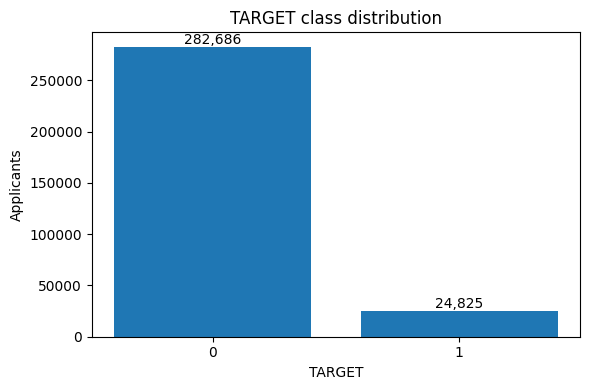

In [5]:
target_counts = application_train['TARGET'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(target_counts.index.astype(str), target_counts.values)
ax.set_title('TARGET class distribution')
ax.set_xlabel('TARGET')
ax.set_ylabel('Applicants')
for i,v in enumerate(target_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

The dataset is heavily imbalanced: **282,686 class-0 applicants (91.93%)** and **24,825 class-1 applicants (8.07%)**. Therefore the project uses ROC-AUC/PR-AUC and class-aware training rather than relying on accuracy alone.

### 3.1 Missingness

In [6]:
missing_summary = pd.DataFrame({
    'missing_count': application_train.isna().sum(),
    'missing_pct': application_train.isna().mean() * 100,
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)
missing_summary.head(30)

,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


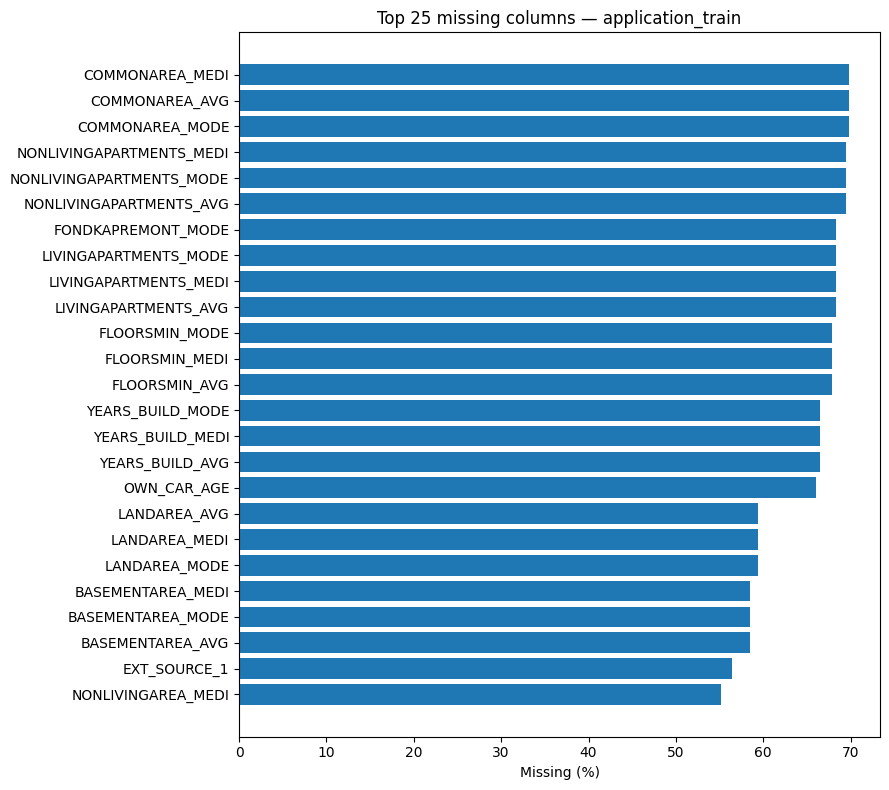

In [7]:
top_missing = missing_summary.head(25).sort_values('missing_pct')
fig, ax = plt.subplots(figsize=(9,8))
ax.barh(top_missing.index, top_missing['missing_pct'])
ax.set_title('Top 25 missing columns — application_train')
ax.set_xlabel('Missing (%)')
plt.tight_layout(); plt.show()

In [8]:
print('EXT_SOURCE_1 missingness vs TARGET:')
print(application_train.groupby(application_train['EXT_SOURCE_1'].isna())['TARGET'].mean())

print()
print('COMMONAREA_AVG missingness vs TARGET:')
print(application_train.groupby(application_train['COMMONAREA_AVG'].isna())['TARGET'].mean())


EXT_SOURCE_1 missingness vs TARGET:
EXT_SOURCE_1
False    0.074955
True     0.085195
Name: TARGET, dtype: float64

COMMONAREA_AVG missingness vs TARGET:
COMMONAREA_AVG
False    0.069102
True     0.085742
Name: TARGET, dtype: float64


Missingness itself carried signal in some variables. For example, `EXT_SOURCE_1` missing had target mean **0.0852** vs **0.0750** when present, while `COMMONAREA_AVG` missing had **0.0857** vs **0.0691**. The later cleaning step removes numerical columns only after the complete merged feature table is built.

## 4. Application-level engineered features + EDA

In [9]:
def add_application_features_train(df):
    out = df.copy()
    out['INCOME_GROUP'], income_bins = pd.qcut(out['AMT_INCOME_TOTAL'], q=5, duplicates='drop', retbins=True)
    out['CREDIT_GROUP'], credit_bins = pd.qcut(out['AMT_CREDIT'], q=5, duplicates='drop', retbins=True)
    out['CREDIT_INCOME_RATIO'] = out['AMT_CREDIT'] / out['AMT_INCOME_TOTAL']
    out['AGE_YEARS'] = -out['DAYS_BIRTH'] / 365
    age_bins = [18,25,35,45,55,65,100]
    out['AGE_GROUP'] = pd.cut(out['AGE_YEARS'], bins=age_bins)
    return out, income_bins, credit_bins, age_bins

def add_application_features_test(df, income_bins, credit_bins, age_bins):
    out = df.copy()
    out['INCOME_GROUP'] = pd.cut(out['AMT_INCOME_TOTAL'], bins=income_bins, include_lowest=True)
    out['CREDIT_GROUP'] = pd.cut(out['AMT_CREDIT'], bins=credit_bins, include_lowest=True)
    out['CREDIT_INCOME_RATIO'] = out['AMT_CREDIT'] / out['AMT_INCOME_TOTAL']
    out['AGE_YEARS'] = -out['DAYS_BIRTH'] / 365
    out['AGE_GROUP'] = pd.cut(out['AGE_YEARS'], bins=age_bins)
    return out

application_train, income_bins, credit_bins, age_bins = add_application_features_train(application_train)
application_test = add_application_features_test(application_test_raw, income_bins, credit_bins, age_bins)
print(application_train.shape, application_test.shape)

(307511, 127) (48744, 126)


In [10]:
def rate_table(df, group_col):
    return df.groupby(group_col, observed=True)['TARGET'].agg(['count','mean']).rename(columns={'mean':'default_rate'})

def plot_rate(table, title, rotate=0):
    labels = [str(x) for x in table.index]
    vals = table['default_rate'] * 100
    fig, ax = plt.subplots(figsize=(8,4.5))
    ax.bar(labels, vals)
    ax.set_title(title); ax.set_ylabel('TARGET=1 rate (%)')
    ax.tick_params(axis='x', rotation=rotate)
    for i,v in enumerate(vals): ax.text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
    plt.tight_layout(); plt.show()

### 4.1 Income

,count,default_rate
INCOME_GROUP,,
"(25649.999, 99000.0]",63671,0.082062
"(99000.0, 135000.0]",85756,0.085883
"(135000.0, 162000.0]",35453,0.086847
"(162000.0, 225000.0]",75513,0.080569
"(225000.0, 117000000.0]",47118,0.065198


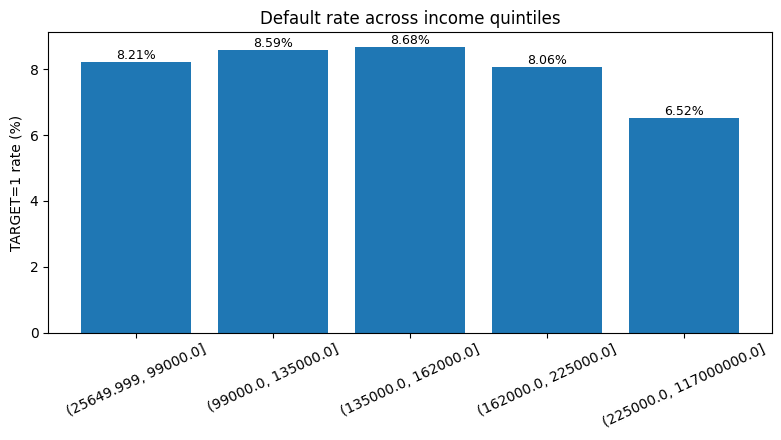

In [11]:
income_risk = rate_table(application_train, 'INCOME_GROUP')
display(income_risk)
plot_rate(income_risk, 'Default rate across income quintiles', 25)

Original target rates were about **8.21%, 8.59%, 8.68%, 8.06%, 6.52%**. The highest-income quintile had the lowest observed difficulty rate, but the relationship was not perfectly linear and was treated as association rather than causation.

### 4.2 Credit amount and credit-to-income ratio

,count,default_rate
CREDIT_GROUP,,
"(44999.999, 254700.0]",64925,0.072376
"(254700.0, 432000.0]",58098,0.091724
"(432000.0, 604152.0]",61552,0.100549
"(604152.0, 900000.0]",64024,0.078549
"(900000.0, 4050000.0]",58912,0.060752


,count,default_rate
CREDIT_INCOME_RATIO,,
"(0.00381, 1.818]",61539,0.073352
"(1.818, 2.764]",61502,0.085672
"(2.764, 3.906]",61466,0.089253
"(3.906, 5.769]",61505,0.082839
"(5.769, 84.737]",61499,0.072538


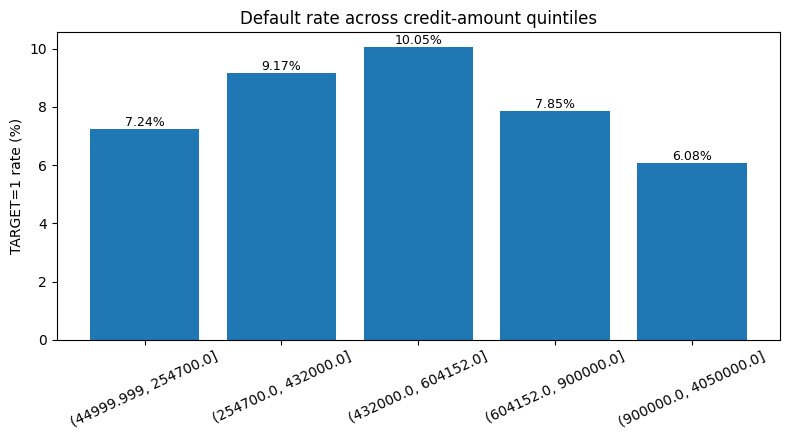

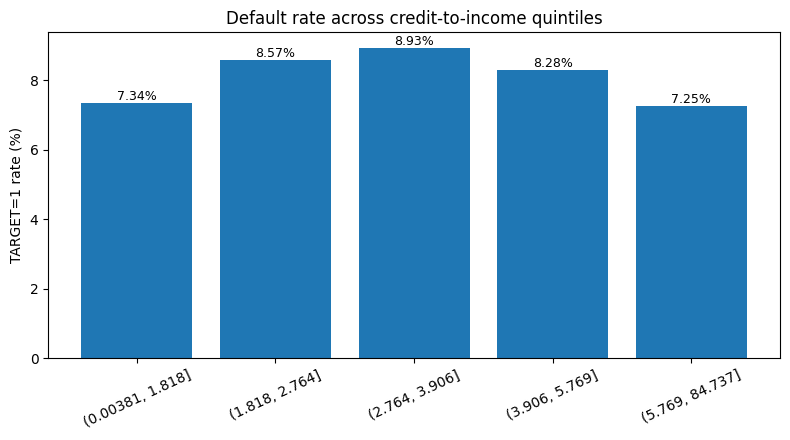

In [12]:
credit_risk = rate_table(application_train, 'CREDIT_GROUP')
ratio_risk = application_train.groupby(
    pd.qcut(application_train['CREDIT_INCOME_RATIO'], 5, duplicates='drop'), observed=True
)['TARGET'].agg(['count','mean']).rename(columns={'mean':'default_rate'})
display(credit_risk); display(ratio_risk)
plot_rate(credit_risk, 'Default rate across credit-amount quintiles', 25)
plot_rate(ratio_risk, 'Default rate across credit-to-income quintiles', 25)

The credit relationship was non-linear: the middle credit quintile had the highest observed target rate (**~10.05%**) and the largest-credit group the lowest (**~6.08%**). Credit-to-income was also non-linear: **~7.34%, 8.57%, 8.93%, 8.28%, 7.25%** across quintiles.

### 4.3 Age, gender, income type and education

,count,default_rate
AGE_GROUP,,
"(18, 25]",12159,0.123036
"(25, 35]",72302,0.106733
"(35, 45]",84274,0.084047
"(45, 55]",70077,0.070580
"(55, 65]",60596,0.054145
"(65, 100]",8103,0.037270


,count,mean
CODE_GENDER,,
M,105059,0.101419
F,202448,0.069993
XNA,4,0.000000


,count,mean
NAME_INCOME_TYPE,,
Maternity leave,5,0.400000
Unemployed,22,0.363636
Working,158774,0.095885
Commercial associate,71617,0.074843
State servant,21703,0.057550
Pensioner,55362,0.053864
Businessman,10,0.000000
Student,18,0.000000


,count,mean
NAME_EDUCATION_TYPE,,
Lower secondary,3816,0.109277
Secondary / secondary special,218391,0.089399
Incomplete higher,10277,0.084850
Higher education,74863,0.053551
Academic degree,164,0.018293


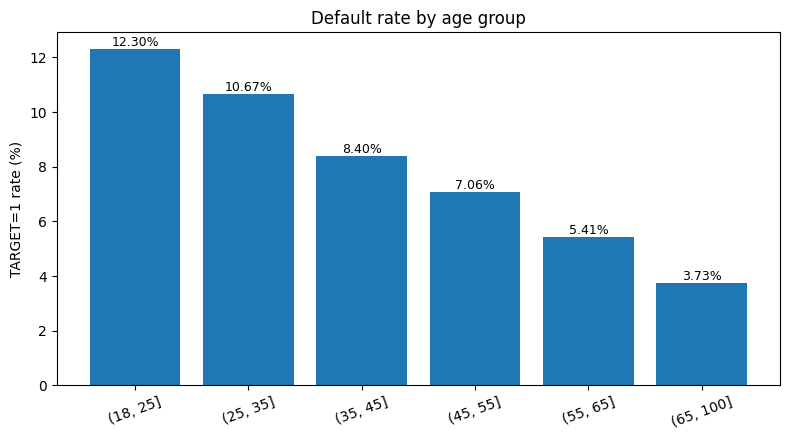

In [13]:
age_risk = rate_table(application_train, 'AGE_GROUP')
gender_risk = application_train.groupby('CODE_GENDER')['TARGET'].agg(['count','mean']).sort_values('mean', ascending=False)
income_type_risk = application_train.groupby('NAME_INCOME_TYPE')['TARGET'].agg(['count','mean']).sort_values('mean', ascending=False)
edu_risk = application_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].agg(['count','mean']).sort_values('mean', ascending=False)

display(age_risk); display(gender_risk); display(income_type_risk); display(edu_risk)
plot_rate(age_risk, 'Default rate by age group', 20)

Age was one of the clearest relationships: **12.30% → 10.67% → 8.40% → 7.06% → 5.41% → 3.73%** as age increased. Male applicants had **10.14%** observed difficulty vs **7.00%** for female applicants. Lower secondary education had **10.93%**, while Higher education had **5.36%**. Tiny income-type categories were not treated as reliable conclusions; among large groups, Working had **9.59%**, Commercial associate **7.48%**, State servant **5.76%**, Pensioner **5.39%**.

## 5. Bureau: applicant credit-history features

In [14]:
print('bureau shape:', bureau.shape)
display(bureau.isna().mean().sort_values(ascending=False).head(10))
display(bureau['CREDIT_ACTIVE'].value_counts())

bureau shape: (1716428, 17)


AMT_ANNUITY               0.714735
AMT_CREDIT_MAX_OVERDUE    0.655133
DAYS_ENDDATE_FACT         0.369170
AMT_CREDIT_SUM_LIMIT      0.344774
AMT_CREDIT_SUM_DEBT       0.150119
DAYS_CREDIT_ENDDATE       0.061496
AMT_CREDIT_SUM            0.000008
SK_ID_CURR                0.000000
SK_ID_BUREAU              0.000000
CREDIT_DAY_OVERDUE        0.000000
dtype: float64

CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

In [15]:
bureau_credit_count = bureau.groupby('SK_ID_CURR').size().rename('BUREAU_CREDIT_COUNT')
bureau_active_count = bureau[bureau['CREDIT_ACTIVE']=='Active'].groupby('SK_ID_CURR').size().rename('BUREAU_ACTIVE_COUNT').reindex(bureau_credit_count.index, fill_value=0)
bureau_active_ratio = (bureau_active_count / bureau_credit_count).rename('BUREAU_ACTIVE_RATIO')

# Training-side definition from the original notebook.
bureau_overdue_count = bureau[bureau['AMT_CREDIT_SUM_OVERDUE'] > 0].groupby('SK_ID_CURR').size().rename('BUREAU_OVERDUE_COUNT').reindex(bureau_credit_count.index, fill_value=0)
bureau_overdue_ratio = (bureau_overdue_count / bureau_credit_count).rename('BUREAU_OVERDUE_RATIO')
bureau_max_overdue_days = bureau.groupby('SK_ID_CURR')['CREDIT_DAY_OVERDUE'].max().rename('BUREAU_MAX_OVERDUE_DAYS')

bureau_features = pd.concat([
    bureau_credit_count, bureau_active_count, bureau_active_ratio,
    bureau_overdue_count, bureau_overdue_ratio, bureau_max_overdue_days
], axis=1)

bureau_debt = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_DEBT'].sum().rename('BUREAU_TOTAL_DEBT')
bureau_features.head()

,BUREAU_CREDIT_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_ACTIVE_RATIO,BUREAU_OVERDUE_COUNT,BUREAU_OVERDUE_RATIO,BUREAU_MAX_OVERDUE_DAYS
SK_ID_CURR,,,,,,
100001,7,3,0.428571,0,0.0,0
100002,8,2,0.250000,0,0.0,0
100003,4,1,0.250000,0,0.0,0
100004,2,0,0.000000,0,0.0,0
100005,3,2,0.666667,0,0.0,0


In [16]:
def merge_bureau_train(app):
    out = app.merge(bureau_features, on='SK_ID_CURR', how='left')
    base = ['BUREAU_CREDIT_COUNT','BUREAU_ACTIVE_COUNT','BUREAU_ACTIVE_RATIO','BUREAU_OVERDUE_COUNT','BUREAU_OVERDUE_RATIO','BUREAU_MAX_OVERDUE_DAYS']
    out[base] = out[base].fillna(0)
    out['HAS_BUREAU_HISTORY'] = out['BUREAU_CREDIT_COUNT'] > 0
    out['HAS_BUREAU_OVERDUE'] = out['BUREAU_OVERDUE_COUNT'] > 0
    out['OVERDUE_SEVERITY'] = pd.cut(out['BUREAU_MAX_OVERDUE_DAYS'], bins=[-1,0,30,90,180,np.inf], labels=['No overdue','1–30 days','31–90 days','91–180 days','180+ days'])
    out['BUREAU_CREDIT_GROUP'] = pd.cut(out['BUREAU_CREDIT_COUNT'], bins=[0,2,5,10,20,np.inf], labels=['1–2 credits','3–5 credits','6–10 credits','11–20 credits','20+ credits'])
    out = out.merge(bureau_debt, on='SK_ID_CURR', how='left')
    out['BUREAU_TOTAL_DEBT'] = out['BUREAU_TOTAL_DEBT'].fillna(0)
    out['BUREAU_DEBT_INCOME_RATIO'] = out['BUREAU_TOTAL_DEBT'] / out['AMT_INCOME_TOTAL']
    out['BUREAU_DEBT_INCOME_GROUP'], debt_bins = pd.qcut(out['BUREAU_DEBT_INCOME_RATIO'], q=5, duplicates='drop', retbins=True)
    # Original domain correction: negative summed debt -> zero.
    out['BUREAU_TOTAL_DEBT'] = out['BUREAU_TOTAL_DEBT'].clip(lower=0)
    out['BUREAU_DEBT_INCOME_RATIO'] = out['BUREAU_TOTAL_DEBT'] / out['AMT_INCOME_TOTAL']
    out['DEBT_INCOME_GROUP'] = pd.cut(out['BUREAU_DEBT_INCOME_RATIO'], bins=[-0.001,0,1,2,4,8,np.inf], labels=['No debt','0–1x income','1–2x income','2–4x income','4–8x income','8x+ income'])
    return out, debt_bins

def merge_bureau_test(app, debt_bins):
    # Consistency cleanup: reuse the same bureau aggregates/definition as train.
    out = app.merge(bureau_features, on='SK_ID_CURR', how='left')
    base = ['BUREAU_CREDIT_COUNT','BUREAU_ACTIVE_COUNT','BUREAU_ACTIVE_RATIO','BUREAU_OVERDUE_COUNT','BUREAU_OVERDUE_RATIO','BUREAU_MAX_OVERDUE_DAYS']
    out[base] = out[base].fillna(0)
    out['HAS_BUREAU_HISTORY'] = out['BUREAU_CREDIT_COUNT'] > 0
    out['HAS_BUREAU_OVERDUE'] = out['BUREAU_OVERDUE_COUNT'] > 0
    out['OVERDUE_SEVERITY'] = pd.cut(out['BUREAU_MAX_OVERDUE_DAYS'], bins=[-1,0,30,90,180,np.inf], labels=['No overdue','1–30 days','31–90 days','91–180 days','180+ days'])
    out['BUREAU_CREDIT_GROUP'] = pd.cut(out['BUREAU_CREDIT_COUNT'], bins=[0,2,5,10,20,np.inf], labels=['1–2 credits','3–5 credits','6–10 credits','11–20 credits','20+ credits'])
    out = out.merge(bureau_debt, on='SK_ID_CURR', how='left')
    out['BUREAU_TOTAL_DEBT'] = out['BUREAU_TOTAL_DEBT'].fillna(0)
    raw_ratio = out['BUREAU_TOTAL_DEBT'] / out['AMT_INCOME_TOTAL']
    out['BUREAU_DEBT_INCOME_GROUP'] = pd.cut(raw_ratio, bins=debt_bins, include_lowest=True)
    out['BUREAU_TOTAL_DEBT'] = out['BUREAU_TOTAL_DEBT'].clip(lower=0)
    out['BUREAU_DEBT_INCOME_RATIO'] = out['BUREAU_TOTAL_DEBT'] / out['AMT_INCOME_TOTAL']
    out['DEBT_INCOME_GROUP'] = pd.cut(out['BUREAU_DEBT_INCOME_RATIO'], bins=[-0.001,0,1,2,4,8,np.inf], labels=['No debt','0–1x income','1–2x income','2–4x income','4–8x income','8x+ income'])
    return out

application_bureau, bureau_debt_bins = merge_bureau_train(application_train)
application_test_bureau = merge_bureau_test(application_test, bureau_debt_bins)
print(application_bureau.shape, application_test_bureau.shape)

(307511, 141) (48744, 140)


### 5.1 Bureau EDA

,count,default_rate
HAS_BUREAU_HISTORY,,
False,44020,0.101249
True,263491,0.077301


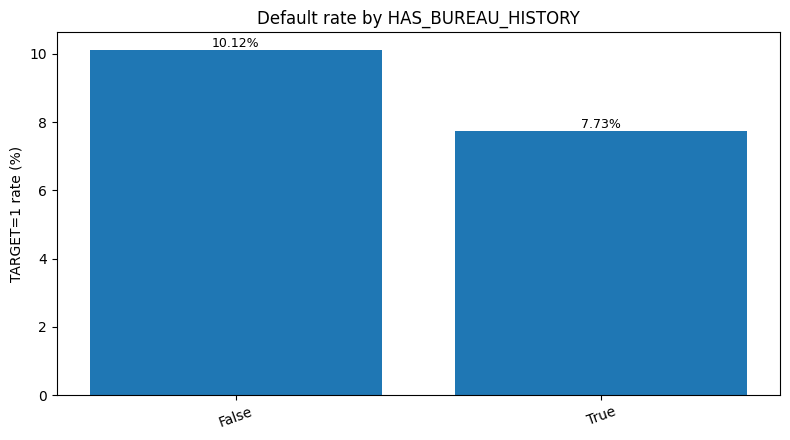

,count,default_rate
HAS_BUREAU_OVERDUE,,
False,304177,0.079838
True,3334,0.161968


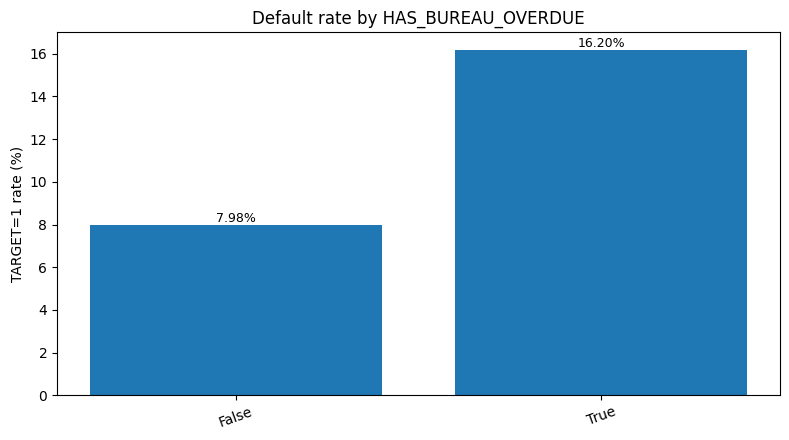

,count,default_rate
OVERDUE_SEVERITY,,
No overdue,304114,0.079855
1–30 days,1523,0.183848
31–90 days,790,0.173418
91–180 days,225,0.155556
180+ days,859,0.102445


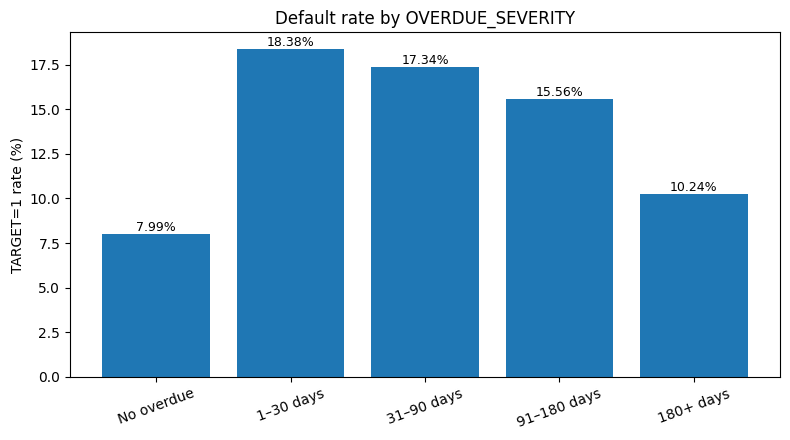

,count,default_rate
BUREAU_CREDIT_GROUP,,
1–2 credits,71707,0.082028
3–5 credits,86883,0.074008
6–10 credits,72624,0.074562
11–20 credits,29808,0.079341
20+ credits,2469,0.111786


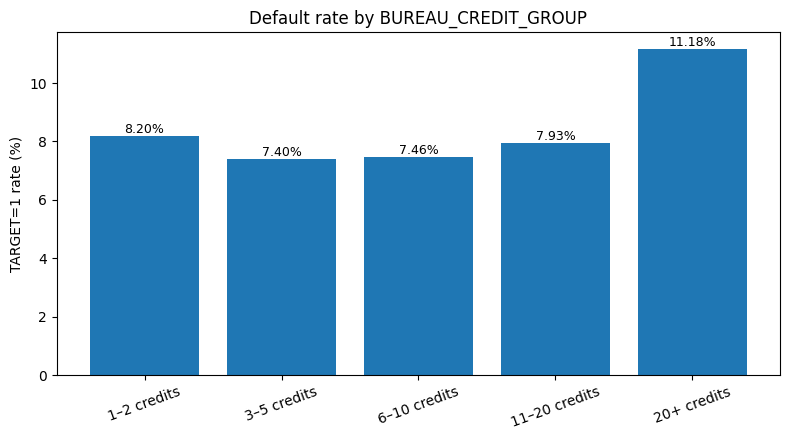

,count,default_rate
DEBT_INCOME_GROUP,,
No debt,122365,0.072717
0–1x income,47216,0.076775
1–2x income,30699,0.082609
2–4x income,37649,0.087545
4–8x income,37170,0.092440
8x+ income,32412,0.093607


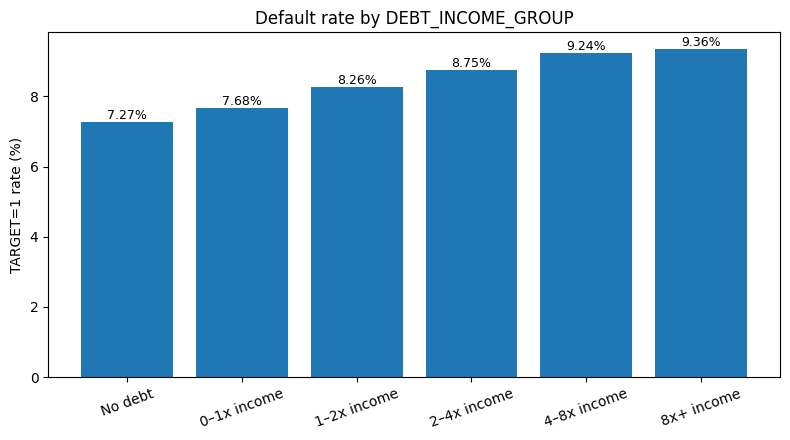

In [17]:
for col in ['HAS_BUREAU_HISTORY','HAS_BUREAU_OVERDUE','OVERDUE_SEVERITY','BUREAU_CREDIT_GROUP','DEBT_INCOME_GROUP']:
    table = rate_table(application_bureau, col)
    display(table)
    plot_rate(table, f'Default rate by {col}', 20)

Key notebook-confirmed findings:
- No bureau history: **10.12%**, with bureau history: **7.73%**.
- Any bureau overdue: **16.20%**, no overdue: **7.98%**.
- Overdue duration itself was non-monotonic, so the project did **not** claim that more overdue days always means higher current risk.
- Debt burden increased more consistently: No debt **7.27%**, 0–1× income **7.68%**, 1–2× **8.26%**, 2–4× **8.75%**, 4–8× **9.24%**, 8×+ **9.36%**.

## 6. Bureau balance: monthly-history features

In [18]:
bureau_months = bureau_balance.groupby('SK_ID_BUREAU').size().rename('BUREAU_MONTHS_REPORTED')
bureau_overdue_months = bureau_balance[bureau_balance['STATUS'].isin(['1','2','3','4','5'])].groupby('SK_ID_BUREAU').size().rename('BUREAU_OVERDUE_MONTHS')
bureau_overdue_month_ratio = bureau_overdue_months.div(bureau_months).rename('BUREAU_OVERDUE_MONTH_RATIO')
bureau_severe_months = bureau_balance[bureau_balance['STATUS'].isin(['3','4','5'])].groupby('SK_ID_BUREAU').size().rename('BUREAU_SEVERE_OVERDUE_MONTHS')
bureau_severe_ratio = bureau_severe_months.div(bureau_months).rename('BUREAU_SEVERE_OVERDUE_RATIO')

bureau_balance_features = pd.concat([
    bureau_months, bureau_overdue_months, bureau_overdue_month_ratio,
    bureau_severe_months, bureau_severe_ratio
], axis=1).fillna({
    'BUREAU_OVERDUE_MONTHS':0,
    'BUREAU_OVERDUE_MONTH_RATIO':0,
    'BUREAU_SEVERE_OVERDUE_MONTHS':0,
    'BUREAU_SEVERE_OVERDUE_RATIO':0,
})

bureau_balance_customer = bureau[['SK_ID_BUREAU','SK_ID_CURR']].merge(bureau_balance_features, on='SK_ID_BUREAU', how='inner')
bureau_balance_customer_features = bureau_balance_customer.groupby('SK_ID_CURR').agg(
    BUREAU_BALANCE_CREDIT_COUNT=('SK_ID_BUREAU','nunique'),
    BUREAU_AVG_MONTHS_REPORTED=('BUREAU_MONTHS_REPORTED','mean'),
    BUREAU_TOTAL_OVERDUE_MONTHS=('BUREAU_OVERDUE_MONTHS','sum'),
    BUREAU_AVG_OVERDUE_RATIO=('BUREAU_OVERDUE_MONTH_RATIO','mean'),
    BUREAU_TOTAL_SEVERE_OVERDUE_MONTHS=('BUREAU_SEVERE_OVERDUE_MONTHS','sum'),
    BUREAU_AVG_SEVERE_OVERDUE_RATIO=('BUREAU_SEVERE_OVERDUE_RATIO','mean'),
    BUREAU_MAX_OVERDUE_RATIO=('BUREAU_OVERDUE_MONTH_RATIO','max'),
)

balance_cols = bureau_balance_customer_features.columns.tolist()

def add_balance(app):
    out = app.merge(bureau_balance_customer_features, on='SK_ID_CURR', how='left')
    out['HAS_BUREAU_BALANCE_HISTORY'] = out['BUREAU_BALANCE_CREDIT_COUNT'].notna()
    out[balance_cols] = out[balance_cols].fillna(0)
    return out

application_bureau_balance = add_balance(application_bureau)
application_test_bureau_balance = add_balance(application_test_bureau)
print(application_bureau_balance.shape, application_test_bureau_balance.shape)

(307511, 149) (48744, 148)


`BUREAU_BALANCE_CREDIT_COUNT` is the number of bureau credits with matched monthly history; the remaining variables summarize history length, overdue months, severe-overdue months and overdue ratios. The organized test path reuses this same aggregate table rather than the original row-level summation that changed the meaning of the test count.

## 7. Previous applications

,mean,count,default_rate_%
NAME_CONTRACT_STATUS,,,
Approved,0.075887,886099,7.588655
Canceled,0.091736,259441,9.173569
Refused,0.119964,245390,11.996414
Unused offer,0.082517,22771,8.251724


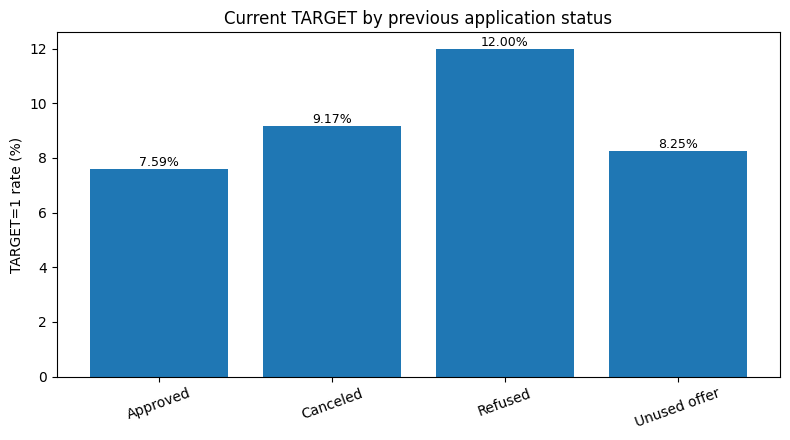

In [19]:
previous_status_eda = previous_application[['SK_ID_CURR','NAME_CONTRACT_STATUS']].merge(
    application_train[['SK_ID_CURR','TARGET']], on='SK_ID_CURR', how='inner'
).groupby('NAME_CONTRACT_STATUS')['TARGET'].agg(['mean','count'])
previous_status_eda['default_rate_%'] = previous_status_eda['mean'] * 100
display(previous_status_eda)
plot_rate(previous_status_eda.rename(columns={'mean':'default_rate'}), 'Current TARGET by previous application status', 20)

Previous status contained predictive information: Approved **7.59%**, Canceled **9.17%**, Refused **12.00%**, Unused offer **8.25%** current target rate. A previously refused application was therefore associated with higher current risk.

In [20]:
previous_features = previous_application.groupby('SK_ID_CURR').agg(
    PREVIOUS_APP_COUNT=('SK_ID_PREV','nunique'),
    PREVIOUS_APPROVED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x=='Approved').sum()),
    PREVIOUS_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x=='Refused').sum()),
    PREVIOUS_CANCELED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x=='Canceled').sum()),
    PREVIOUS_UNUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x=='Unused offer').sum()),
    PREVIOUS_AVG_CREDIT=('AMT_CREDIT','mean'),
    PREVIOUS_AVG_APPLICATION=('AMT_APPLICATION','mean'),
)
previous_features['PREVIOUS_APPROVAL_RATE'] = previous_features['PREVIOUS_APPROVED_COUNT'] / previous_features['PREVIOUS_APP_COUNT']
previous_features['PREVIOUS_REFUSAL_RATE'] = previous_features['PREVIOUS_REFUSED_COUNT'] / previous_features['PREVIOUS_APP_COUNT']
prev_cols = previous_features.columns.tolist()

def add_previous(app):
    out = app.merge(previous_features, on='SK_ID_CURR', how='left')
    out[prev_cols] = out[prev_cols].fillna(0)
    return out

application_previous = add_previous(application_bureau_balance)
application_test_previous = add_previous(application_test_bureau_balance)
print(application_previous.shape, application_test_previous.shape)

(307511, 158) (48744, 157)


## 8. Installment-payment behavior

In [21]:
installments = installments.copy()
installments['PAYMENT_DELAY'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
print('Late installment rows (%):', (installments['PAYMENT_DELAY'] > 0).mean() * 100)

a = installments[installments['PAYMENT_DELAY'] > 0].groupby('SK_ID_CURR').size().rename('LATE_PAYMENT_COUNT')
total = installments.groupby('SK_ID_CURR').size()
b = a.div(total).rename('LATE_PAYMENT_RATE')
c = installments.groupby('SK_ID_CURR')['PAYMENT_DELAY'].mean().rename('AVG_PAYMENT_DELAY')
underpaid = ((installments['AMT_PAYMENT'] < installments['AMT_INSTALMENT']) & installments['AMT_PAYMENT'].notna())
d = underpaid.groupby(installments['SK_ID_CURR']).mean().rename('UNDERPAYMENT_RATE')
installment_features = pd.concat([a,b,c,d], axis=1)

def add_installments(app):
    return app.merge(installment_features, on='SK_ID_CURR', how='left')

application_full = add_installments(application_previous)
application_test_full = add_installments(application_test_previous)
print('Enriched train:', application_full.shape)
print('Enriched test :', application_test_full.shape)

Late installment rows (%): 8.428042657471103
Enriched train: (307511, 162)
Enriched test : (48744, 161)


The original notebook found **8.43% of installment rows were late**. At applicant level, `LATE_PAYMENT_RATE` and `AVG_PAYMENT_DELAY` had weak/non-monotonic univariate relationships with TARGET, but they were retained because they may contribute through interactions with other variables.

In [22]:
late_eda_df = application_full.dropna(subset=['LATE_PAYMENT_RATE'])
late_rate_eda = late_eda_df.groupby(pd.qcut(late_eda_df['LATE_PAYMENT_RATE'],5,duplicates='drop'), observed=True)['TARGET'].agg(['count','mean'])
avg_delay_df = application_full.dropna(subset=['AVG_PAYMENT_DELAY'])
avg_delay_eda = avg_delay_df.groupby(pd.qcut(avg_delay_df['AVG_PAYMENT_DELAY'],5,duplicates='drop'), observed=True)['TARGET'].agg(['count','mean'])
display(late_rate_eda); display(avg_delay_eda)

,count,mean
LATE_PAYMENT_RATE,,
"(0.0025599999999999998, 0.0408]",31118,0.067132
"(0.0408, 0.0794]",30928,0.083484
"(0.0794, 0.136]",31311,0.094951
"(0.136, 0.231]",31152,0.100539
"(0.231, 1.0]",30490,0.124861


,count,mean
AVG_PAYMENT_DELAY,,
"(-295.001, -16.5]",58537,0.069614
"(-16.5, -11.294]",58119,0.072541
"(-11.294, -8.0]",59175,0.079966
"(-8.0, -5.11]",57477,0.086504
"(-5.11, 1884.205]",58327,0.100811


## 9. Audit the 40 added features and their source

In [23]:
original_cols = pd.read_csv(DATA_PATH / 'application_train.csv', nrows=1).columns.tolist()
extra_cols = [c for c in application_full.columns if c not in original_cols]
print('Total extra columns:', len(extra_cols))
print('Duplicate column names:', application_full.columns[application_full.columns.duplicated()].tolist())
for i,c in enumerate(extra_cols,1): print(f'{i:2}. {c}')

Total extra columns: 40
Duplicate column names: []
 1. INCOME_GROUP
 2. CREDIT_GROUP
 3. CREDIT_INCOME_RATIO
 4. AGE_YEARS
 5. AGE_GROUP
 6. BUREAU_CREDIT_COUNT
 7. BUREAU_ACTIVE_COUNT
 8. BUREAU_ACTIVE_RATIO
 9. BUREAU_OVERDUE_COUNT
10. BUREAU_OVERDUE_RATIO
11. BUREAU_MAX_OVERDUE_DAYS
12. HAS_BUREAU_HISTORY
13. HAS_BUREAU_OVERDUE
14. OVERDUE_SEVERITY
15. BUREAU_CREDIT_GROUP
16. BUREAU_TOTAL_DEBT
17. BUREAU_DEBT_INCOME_RATIO
18. BUREAU_DEBT_INCOME_GROUP
19. DEBT_INCOME_GROUP
20. BUREAU_BALANCE_CREDIT_COUNT
21. BUREAU_AVG_MONTHS_REPORTED
22. BUREAU_TOTAL_OVERDUE_MONTHS
23. BUREAU_AVG_OVERDUE_RATIO
24. BUREAU_TOTAL_SEVERE_OVERDUE_MONTHS
25. BUREAU_AVG_SEVERE_OVERDUE_RATIO
26. BUREAU_MAX_OVERDUE_RATIO
27. HAS_BUREAU_BALANCE_HISTORY
28. PREVIOUS_APP_COUNT
29. PREVIOUS_APPROVED_COUNT
30. PREVIOUS_REFUSED_COUNT
31. PREVIOUS_CANCELED_COUNT
32. PREVIOUS_UNUSED_COUNT
33. PREVIOUS_AVG_CREDIT
34. PREVIOUS_AVG_APPLICATION
35. PREVIOUS_APPROVAL_RATE
36. PREVIOUS_REFUSAL_RATE
37. LATE_PAYMENT_COUNT


In [24]:
feature_lineage = pd.DataFrame([
('INCOME_GROUP','application_train'),('CREDIT_GROUP','application_train'),('CREDIT_INCOME_RATIO','application_train'),('AGE_YEARS','application_train'),('AGE_GROUP','application_train'),
('BUREAU_CREDIT_COUNT','bureau'),('BUREAU_ACTIVE_COUNT','bureau'),('BUREAU_ACTIVE_RATIO','bureau'),('BUREAU_OVERDUE_COUNT','bureau'),('BUREAU_OVERDUE_RATIO','bureau'),('BUREAU_MAX_OVERDUE_DAYS','bureau'),('HAS_BUREAU_HISTORY','bureau'),('HAS_BUREAU_OVERDUE','bureau'),('OVERDUE_SEVERITY','bureau'),('BUREAU_CREDIT_GROUP','bureau'),('BUREAU_TOTAL_DEBT','bureau'),('BUREAU_DEBT_INCOME_RATIO','bureau + application'),('BUREAU_DEBT_INCOME_GROUP','bureau + application'),('DEBT_INCOME_GROUP','bureau + application'),
('BUREAU_BALANCE_CREDIT_COUNT','bureau_balance + bureau'),('BUREAU_AVG_MONTHS_REPORTED','bureau_balance + bureau'),('BUREAU_TOTAL_OVERDUE_MONTHS','bureau_balance + bureau'),('BUREAU_AVG_OVERDUE_RATIO','bureau_balance + bureau'),('BUREAU_TOTAL_SEVERE_OVERDUE_MONTHS','bureau_balance + bureau'),('BUREAU_AVG_SEVERE_OVERDUE_RATIO','bureau_balance + bureau'),('BUREAU_MAX_OVERDUE_RATIO','bureau_balance + bureau'),('HAS_BUREAU_BALANCE_HISTORY','bureau_balance + bureau'),
('PREVIOUS_APP_COUNT','previous_application'),('PREVIOUS_APPROVED_COUNT','previous_application'),('PREVIOUS_REFUSED_COUNT','previous_application'),('PREVIOUS_CANCELED_COUNT','previous_application'),('PREVIOUS_UNUSED_COUNT','previous_application'),('PREVIOUS_AVG_CREDIT','previous_application'),('PREVIOUS_AVG_APPLICATION','previous_application'),('PREVIOUS_APPROVAL_RATE','previous_application'),('PREVIOUS_REFUSAL_RATE','previous_application'),
('LATE_PAYMENT_COUNT','installments_payments'),('LATE_PAYMENT_RATE','installments_payments'),('AVG_PAYMENT_DELAY','installments_payments'),('UNDERPAYMENT_RATE','installments_payments')
], columns=['feature','source'])
assert len(feature_lineage) == 40
feature_lineage

,feature,source
0,INCOME_GROUP,application_train
1,CREDIT_GROUP,application_train
2,CREDIT_INCOME_RATIO,application_train
3,AGE_YEARS,application_train
4,AGE_GROUP,application_train
5,BUREAU_CREDIT_COUNT,bureau
6,BUREAU_ACTIVE_COUNT,bureau
7,BUREAU_ACTIVE_RATIO,bureau
8,BUREAU_OVERDUE_COUNT,bureau
9,BUREAU_OVERDUE_RATIO,bureau


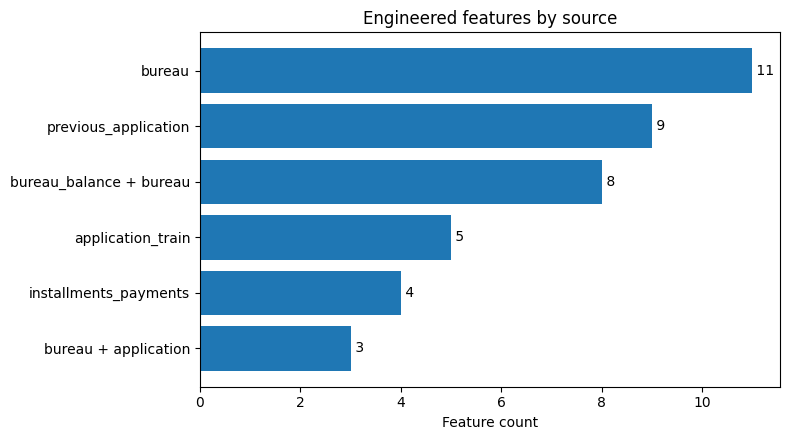

In [25]:
source_counts = feature_lineage['source'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8,4.5))
ax.barh(source_counts.index, source_counts.values)
ax.set_title('Engineered features by source')
ax.set_xlabel('Feature count')
for i,v in enumerate(source_counts.values): ax.text(v, i, f' {v}', va='center')
plt.tight_layout(); plt.show()

## 10. Cleaning: duplicates, missing values, infinities and outliers

In [26]:
train_clean = application_full.copy(); test_clean = application_test_full.copy()
print('Start:', train_clean.shape, test_clean.shape)
print('Duplicate train SK_ID_CURR:', train_clean['SK_ID_CURR'].duplicated().sum())
print('Duplicate test SK_ID_CURR :', test_clean['SK_ID_CURR'].duplicated().sum())

Start: (307511, 162) (48744, 161)
Duplicate train SK_ID_CURR: 0
Duplicate test SK_ID_CURR : 0


In [27]:
train_cat = train_clean.select_dtypes(include=['object','category','bool']).columns.tolist()
test_cat = test_clean.select_dtypes(include=['object','category','bool']).columns.tolist()
train_clean[train_cat] = train_clean[train_cat].astype('object').fillna('Missing')
test_clean[test_cat] = test_clean[test_cat].astype('object').fillna('Missing')

In [28]:
train_num = train_clean.select_dtypes(include=np.number).columns.tolist()
num_missing = pd.DataFrame({
    'missing_count': train_clean[train_num].isna().sum(),
    'missing_percent': train_clean[train_num].isna().mean()*100,
}).sort_values('missing_percent', ascending=False)
high_missing_cols = num_missing[num_missing['missing_percent'] > 50].index.tolist()
print('Columns removed for >50% numerical missingness:', len(high_missing_cols))
display(num_missing.loc[high_missing_cols])
train_clean = train_clean.drop(columns=high_missing_cols)
test_clean = test_clean.drop(columns=[c for c in high_missing_cols if c in test_clean])
print('After drop:', train_clean.shape, test_clean.shape)

Columns removed for >50% numerical missingness: 38


,missing_count,missing_percent
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953
FLOORSMIN_AVG,208642,67.848630


After drop: (307511, 124) (48744, 123)


The source run removed **38 numerical columns**, producing the **162 → 124** training-table reduction. These included the highly missing building/housing variables and `EXT_SOURCE_1`.

In [29]:
num_cols = [c for c in train_clean.select_dtypes(include=np.number).columns if c != 'TARGET']
train_medians = train_clean[num_cols].median()
train_clean[num_cols] = train_clean[num_cols].fillna(train_medians)
common_test_num = [c for c in num_cols if c in test_clean]
test_clean[common_test_num] = test_clean[common_test_num].fillna(train_medians[common_test_num])
print('Remaining train missing:', train_clean.isna().sum().sum())
print('Remaining test missing :', test_clean.isna().sum().sum())

Remaining train missing: 0
Remaining test missing : 0


Remaining numerical missing values are filled by **median**. In this organized version, test values use the **training medians**, preventing test-distribution leakage.

In [30]:
num_for_outliers = train_clean.drop(columns='TARGET').select_dtypes(include=np.number)
print('Infinite numerical values:', np.isinf(num_for_outliers.to_numpy()).sum())
Q1 = num_for_outliers.quantile(.25); Q3 = num_for_outliers.quantile(.75); IQR = Q3-Q1
outlier_counts = (((num_for_outliers < Q1-1.5*IQR) | (num_for_outliers > Q3+1.5*IQR)).sum().sort_values(ascending=False))
display(outlier_counts[outlier_counts>0].head(30))

Infinite numerical values: 0


LATE_PAYMENT_RATE               147186
LATE_PAYMENT_COUNT              142724
YEARS_BEGINEXPLUATATION_MEDI    142141
YEARS_BEGINEXPLUATATION_AVG     142016
TOTALAREA_MODE                  141917
YEARS_BEGINEXPLUATATION_MODE    141861
FLOORSMAX_AVG                    92616
FLOORSMAX_MEDI                   90884
FLOORSMAX_MODE                   88941
REGION_RATING_CLIENT             80527
REGION_RATING_CLIENT_W_CITY      78027
DAYS_EMPLOYED                    72217
REG_CITY_NOT_WORK_CITY           70867
FLAG_WORK_PHONE                  61308
FLAG_EMP_PHONE                   55386
LIVE_CITY_NOT_WORK_CITY          55215
AMT_REQ_CREDIT_BUREAU_QRT        50575
AMT_REQ_CREDIT_BUREAU_MON        43759
BUREAU_AVG_MONTHS_REPORTED       38372
BUREAU_BALANCE_CREDIT_COUNT      37752
DEF_30_CNT_SOCIAL_CIRCLE         35166
UNDERPAYMENT_RATE                34684
PREVIOUS_CANCELED_COUNT          34591
BUREAU_TOTAL_DEBT                33053
BUREAU_MAX_OVERDUE_RATIO         31052
BUREAU_TOTAL_OVERDUE_MONT

The IQR step in the original notebook **detected** outliers; it did not globally delete or cap them. The actual explicit domain correction was clipping negative `BUREAU_TOTAL_DEBT` to zero.

In [31]:
housing_redundant = ['YEARS_BEGINEXPLUATATION_AVG','YEARS_BEGINEXPLUATATION_MODE','FLOORSMAX_AVG','FLOORSMAX_MODE']
train_clean = train_clean.drop(columns=housing_redundant)
test_clean = test_clean.drop(columns=housing_redundant)
print('After 4 extra redundant housing drops:', train_clean.shape, test_clean.shape)

After 4 extra redundant housing drops: (307511, 120) (48744, 119)


## 11. Shared mappings before the two modeling branches

In [32]:
binary_maps = {
    'NAME_CONTRACT_TYPE': {'Cash loans':0,'Revolving loans':1},
    'FLAG_OWN_CAR': {'N':0,'Y':1},
    'FLAG_OWN_REALTY': {'N':0,'Y':1},
    'HAS_BUREAU_HISTORY': {False:0,True:1},
    'HAS_BUREAU_OVERDUE': {False:0,True:1},
    'HAS_BUREAU_BALANCE_HISTORY': {False:0,True:1},
}
education_order = {'Lower secondary':1,'Secondary / secondary special':2,'Incomplete higher':3,'Higher education':4,'Academic degree':5}
overdue_order = {'No overdue':1,'1–30 days':2,'31–90 days':3,'91–180 days':4,'180+ days':5}
debt_order = {'No debt':0,'0–1x income':1,'1–2x income':2,'2–4x income':3,'4–8x income':4,'8x+ income':5}
bureau_credit_order = {'Missing':0,'1–2 credits':1,'3–5 credits':2,'6–10 credits':3,'11–20 credits':4,'20+ credits':5}

def shared_maps(df):
    out = df.copy()
    for c,m in binary_maps.items(): out[c] = out[c].map(m)
    out['NAME_EDUCATION_TYPE'] = out['NAME_EDUCATION_TYPE'].map(education_order)
    out['OVERDUE_SEVERITY'] = out['OVERDUE_SEVERITY'].map(overdue_order)
    out['DEBT_INCOME_GROUP'] = out['DEBT_INCOME_GROUP'].map(debt_order)
    out['BUREAU_CREDIT_GROUP'] = out['BUREAU_CREDIT_GROUP'].map(bureau_credit_order)
    out['CODE_GENDER'] = out['CODE_GENDER'].replace('XNA','Other').map({'F':0,'M':1,'Other':0})
    return out

mapped_train = shared_maps(train_clean)
mapped_test = shared_maps(test_clean)
print(mapped_train.shape, mapped_test.shape)

(307511, 120) (48744, 119)


After the shared binary/ordinal mappings, the pipeline branches:

- **Numeric models:** convert every remaining categorical feature to numbers using frequency encoding, categorical screening and one-hot encoding.
- **CatBoost:** preserve the remaining 11 categorical columns as strings and let CatBoost handle them natively.

## 12. Numeric-model branch: frequency encoding + categorical screening + one-hot encoding

In [33]:
y_full = mapped_train['TARGET'].copy()
numeric_train = mapped_train.drop(columns='TARGET').copy()
numeric_test = mapped_test.copy()

occ_freq = mapped_train['OCCUPATION_TYPE'].value_counts(normalize=True)
org_freq = mapped_train['ORGANIZATION_TYPE'].value_counts(normalize=True)
for df in [numeric_train,numeric_test]:
    df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].map(occ_freq).fillna(0)
    df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].map(org_freq).fillna(0)

In [34]:
remaining_cat_cols = ['NAME_TYPE_SUITE','NAME_INCOME_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','WEEKDAY_APPR_PROCESS_START','FONDKAPREMONT_MODE','HOUSETYPE_MODE','WALLSMATERIAL_MODE','EMERGENCYSTATE_MODE']
rows=[]
for col in remaining_cat_cols:
    table = pd.crosstab(numeric_train[col], y_full)
    chi2,p,dof,expected = chi2_contingency(table)
    n = table.to_numpy().sum(); r,k = table.shape
    v = np.sqrt(chi2 / (n * min(r-1,k-1)))
    rows.append({'Feature':col,'p_value':p,'Cramers_V':v})
association_results = pd.DataFrame(rows).sort_values('Cramers_V', ascending=False)
display(association_results)

,Feature,p_value,Cramers_V
1,NAME_INCOME_TYPE,1.928146e-266,0.063845
7,WALLSMATERIAL_MODE,3.916842e-125,0.044137
8,EMERGENCYSTATE_MODE,1.019821e-119,0.042213
6,HOUSETYPE_MODE,4.369310e-110,0.040701
2,NAME_FAMILY_STATUS,7.744842e-107,0.040512
3,NAME_HOUSING_TYPE,1.099089e-88,0.036981
5,FONDKAPREMONT_MODE,9.504317e-60,0.030267
0,NAME_TYPE_SUITE,1.256203e-07,0.012122
4,WEEKDAY_APPR_PROCESS_START,1.744737e-02,0.007074


Recorded Cramér's V: `NAME_INCOME_TYPE` **0.063845**, `WALLSMATERIAL_MODE` **0.044137**, `EMERGENCYSTATE_MODE` **0.042213**. The implemented project retained those three for one-hot encoding and dropped six others.

In [35]:
drop_cat_cols = ['NAME_TYPE_SUITE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','WEEKDAY_APPR_PROCESS_START','FONDKAPREMONT_MODE','HOUSETYPE_MODE']
numeric_train = numeric_train.drop(columns=drop_cat_cols)
numeric_test = numeric_test.drop(columns=drop_cat_cols)

rare_income = ['Unemployed','Student','Businessman','Maternity leave']
for df in [numeric_train,numeric_test]: df['NAME_INCOME_TYPE'] = df['NAME_INCOME_TYPE'].replace(rare_income,'Other')
selected_cat_cols = ['NAME_INCOME_TYPE','WALLSMATERIAL_MODE','EMERGENCYSTATE_MODE']

numeric_train = pd.get_dummies(numeric_train, columns=selected_cat_cols, drop_first=True)
numeric_test = pd.get_dummies(numeric_test, columns=selected_cat_cols, drop_first=True)
numeric_train, numeric_test = numeric_train.align(numeric_test, join='left', axis=1, fill_value=0)
print('After OHE:', numeric_train.shape, numeric_test.shape)

After OHE: (307511, 123) (48744, 123)


In [36]:
interval_cols = ['INCOME_GROUP','CREDIT_GROUP','AGE_GROUP','BUREAU_DEBT_INCOME_GROUP']
for col in interval_cols:
    vals = pd.Series(numeric_train[col]).dropna().unique().tolist()
    vals = [v for v in vals if v != 'Missing']
    vals = sorted(vals, key=lambda x: (getattr(x,'left',-np.inf), getattr(x,'right',np.inf)))
    numeric_train[col] = pd.Categorical(numeric_train[col], categories=vals, ordered=True).codes
    numeric_test[col] = pd.Categorical(numeric_test[col], categories=vals, ordered=True).codes

for df in [numeric_train,numeric_test]:
    bcols = df.select_dtypes(include='bool').columns
    df[bcols] = df[bcols].astype(int)

# Fill any test-only gaps with train medians.
med = numeric_train.select_dtypes(include=np.number).median()
for c in numeric_test.columns:
    if numeric_test[c].isna().any(): numeric_test[c] = numeric_test[c].fillna(med.get(c,0))

print('Non-numeric train:', numeric_train.select_dtypes(exclude=np.number).columns.tolist())
print('Non-numeric test :', numeric_test.select_dtypes(exclude=np.number).columns.tolist())

Non-numeric train: []
Non-numeric test : []


In [37]:
train_ids = numeric_train['SK_ID_CURR'].copy(); test_ids = numeric_test['SK_ID_CURR'].copy()
numeric_train = numeric_train.drop(columns='SK_ID_CURR')
numeric_test = numeric_test.drop(columns='SK_ID_CURR')
print('Before final redundancy removal:', numeric_train.shape, numeric_test.shape)

Before final redundancy removal: (307511, 122) (48744, 122)


The original checkpoint here was **307,511 × 122 train predictors** and **48,744 × 122 test predictors**, with no ID leakage and no missing values.

## 13. Correlation/redundancy reduction: 122 → 107

In [38]:
X_tmp, Xv_tmp, yt_tmp, yv_tmp = train_test_split(numeric_train, y_full, test_size=.2, stratify=y_full, random_state=RANDOM_STATE)
corr = X_tmp.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().sort_values(ascending=False)
high_corr_pairs.head(20)

DAYS_BIRTH                  AGE_YEARS                      1.000000
DAYS_EMPLOYED               FLAG_EMP_PHONE                 0.999735
                            NAME_INCOME_TYPE_Pensioner     0.999540
FLAG_EMP_PHONE              NAME_INCOME_TYPE_Pensioner     0.999503
OBS_30_CNT_SOCIAL_CIRCLE    OBS_60_CNT_SOCIAL_CIRCLE       0.998516
AMT_CREDIT                  AMT_GOODS_PRICE                0.986757
PREVIOUS_AVG_CREDIT         PREVIOUS_AVG_APPLICATION       0.977080
AGE_YEARS                   AGE_GROUP                      0.971639
DAYS_BIRTH                  AGE_GROUP                      0.971639
REGION_RATING_CLIENT        REGION_RATING_CLIENT_W_CITY    0.951187
BUREAU_DEBT_INCOME_GROUP    DEBT_INCOME_GROUP              0.949460
BUREAU_OVERDUE_COUNT        HAS_BUREAU_OVERDUE             0.933796
WALLSMATERIAL_MODE_Missing  EMERGENCYSTATE_MODE_No         0.924955
BUREAU_CREDIT_COUNT         BUREAU_CREDIT_GROUP            0.908248
AMT_CREDIT                  CREDIT_GROUP        

The strongest pair was `DAYS_BIRTH` and engineered `AGE_YEARS` with correlation **1.0**. The project manually removed 15 redundant features based on these high-correlation/duplicate-information checks.

In [39]:
redundant_cols = [
'DAYS_BIRTH','OBS_60_CNT_SOCIAL_CIRCLE','AMT_GOODS_PRICE','PREVIOUS_AVG_APPLICATION','REGION_RATING_CLIENT_W_CITY','BUREAU_CREDIT_GROUP','CNT_FAM_MEMBERS','REG_REGION_NOT_WORK_REGION','DEF_60_CNT_SOCIAL_CIRCLE','REG_CITY_NOT_WORK_CITY','BUREAU_AVG_MONTHS_REPORTED','BUREAU_AVG_OVERDUE_RATIO','PREVIOUS_APPROVED_COUNT','BUREAU_AVG_SEVERE_OVERDUE_RATIO','PREVIOUS_UNUSED_COUNT']

numeric_train_107 = numeric_train.drop(columns=redundant_cols)
numeric_test_107 = numeric_test.drop(columns=redundant_cols)
X_train, X_val, y_train, y_val = train_test_split(numeric_train_107, y_full, test_size=.2, stratify=y_full, random_state=RANDOM_STATE)
print('X_train:', X_train.shape)
print('X_val  :', X_val.shape)
print('X_test :', numeric_test_107.shape)
assert X_train.shape == (246008,107)
assert X_val.shape == (61503,107)

X_train: (246008, 107)
X_val  : (61503, 107)
X_test : (48744, 107)


## 14. Save the processed 107-feature matrices

In [40]:
X_train.to_csv(PROCESSED_PATH/'X_train.csv', index=False)
X_val.to_csv(PROCESSED_PATH/'X_val.csv', index=False)
y_train.to_csv(PROCESSED_PATH/'y_train.csv', index=False)
y_val.to_csv(PROCESSED_PATH/'y_val.csv', index=False)
numeric_test_107.to_csv(PROCESSED_PATH/'application_test.csv', index=False)
print('Saved processed matrices to', PROCESSED_PATH)

Saved processed matrices to C:\Mim\6th trimester\Data Analytics\Main project\home-credit-default-risk\processed


## 15. Random-Forest feature selection

In [41]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')
rf_selector.fit(X_train, y_train)
feature_importance = pd.DataFrame({'feature':X_train.columns,'importance':rf_selector.feature_importances_}).sort_values('importance',ascending=False).reset_index(drop=True)
feature_importance['cumulative_importance'] = feature_importance['importance'].cumsum()
display(feature_importance.head(40))

,feature,importance,cumulative_importance
0,EXT_SOURCE_2,0.072479,0.072479
1,EXT_SOURCE_3,0.062897,0.135376
2,AGE_YEARS,0.036453,0.171829
3,DAYS_EMPLOYED,0.033253,0.205082
4,DAYS_ID_PUBLISH,0.032466,0.237548
5,DAYS_LAST_PHONE_CHANGE,0.032324,0.269872
6,DAYS_REGISTRATION,0.031650,0.301521
7,AVG_PAYMENT_DELAY,0.031554,0.333076
8,AMT_ANNUITY,0.030341,0.363416
9,CREDIT_INCOME_RATIO,0.029938,0.393355


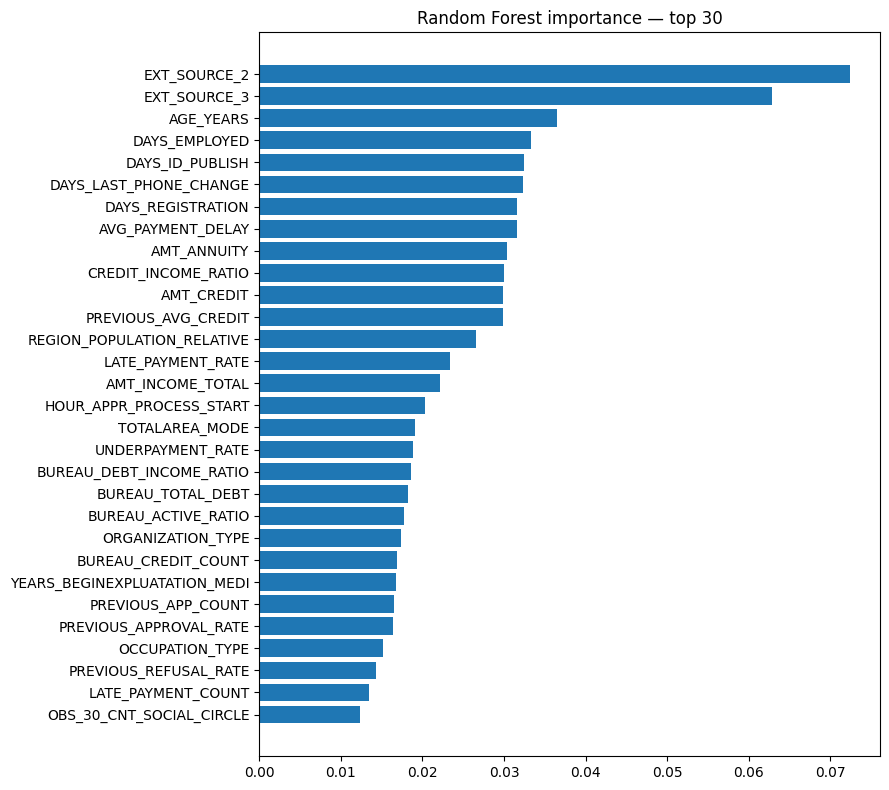

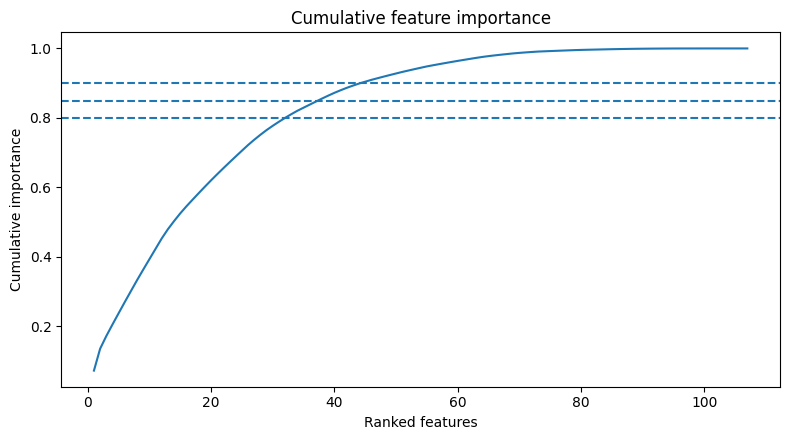

In [42]:
top = feature_importance.head(30).sort_values('importance')
fig, ax = plt.subplots(figsize=(9,8)); ax.barh(top['feature'], top['importance']); ax.set_title('Random Forest importance — top 30'); plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(8,4.5)); ax.plot(np.arange(1,len(feature_importance)+1), feature_importance['cumulative_importance']);
for t in [.80,.85,.90]: ax.axhline(t, linestyle='--')
ax.set_title('Cumulative feature importance'); ax.set_xlabel('Ranked features'); ax.set_ylabel('Cumulative importance'); plt.tight_layout(); plt.show()

In [43]:
cutoffs={}
for t in [.80,.85,.90]: cutoffs[t] = int((feature_importance['cumulative_importance'] < t).sum()+1)
print(cutoffs)
selected_features = feature_importance.head(40)['feature'].tolist()
print('Top-40 selected features:')
for i,c in enumerate(selected_features,1): print(f'{i:2}. {c}')
X_train_selected = X_train[selected_features]; X_val_selected = X_val[selected_features]; X_test_selected = numeric_test_107[selected_features]

{0.8: 33, 0.85: 38, 0.9: 45}
Top-40 selected features:
 1. EXT_SOURCE_2
 2. EXT_SOURCE_3
 3. AGE_YEARS
 4. DAYS_EMPLOYED
 5. DAYS_ID_PUBLISH
 6. DAYS_LAST_PHONE_CHANGE
 7. DAYS_REGISTRATION
 8. AVG_PAYMENT_DELAY
 9. AMT_ANNUITY
10. CREDIT_INCOME_RATIO
11. AMT_CREDIT
12. PREVIOUS_AVG_CREDIT
13. REGION_POPULATION_RELATIVE
14. LATE_PAYMENT_RATE
15. AMT_INCOME_TOTAL
16. HOUR_APPR_PROCESS_START
17. TOTALAREA_MODE
18. UNDERPAYMENT_RATE
19. BUREAU_DEBT_INCOME_RATIO
20. BUREAU_TOTAL_DEBT
21. BUREAU_ACTIVE_RATIO
22. ORGANIZATION_TYPE
23. BUREAU_CREDIT_COUNT
24. YEARS_BEGINEXPLUATATION_MEDI
25. PREVIOUS_APP_COUNT
26. PREVIOUS_APPROVAL_RATE
27. OCCUPATION_TYPE
28. PREVIOUS_REFUSAL_RATE
29. LATE_PAYMENT_COUNT
30. OBS_30_CNT_SOCIAL_CIRCLE
31. AMT_REQ_CREDIT_BUREAU_YEAR
32. BUREAU_ACTIVE_COUNT
33. NAME_EDUCATION_TYPE
34. AGE_GROUP
35. INCOME_GROUP
36. BUREAU_BALANCE_CREDIT_COUNT
37. CREDIT_GROUP
38. PREVIOUS_REFUSED_COUNT
39. FLOORSMAX_MEDI
40. PREVIOUS_CANCELED_COUNT


The recorded selector cutoffs were **33 / 38 / 45** features for 80% / 85% / 90% cumulative importance. The project chose the top 40 for baseline model comparison.

## 16. Baseline models and standardization

In [44]:
scaler_40 = StandardScaler()
X_train_scaled_40 = scaler_40.fit_transform(X_train_selected)
X_val_scaled_40 = scaler_40.transform(X_val_selected)

lr_40 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_40.fit(X_train_scaled_40, y_train)
y_val_pred_lr40 = lr_40.predict(X_val_scaled_40)
y_val_prob_lr40 = lr_40.predict_proba(X_val_scaled_40)[:,1]
print('LR top40:', accuracy_score(y_val,y_val_pred_lr40), precision_score(y_val,y_val_pred_lr40), recall_score(y_val,y_val_pred_lr40), f1_score(y_val,y_val_pred_lr40), roc_auc_score(y_val,y_val_prob_lr40))

LR top40: 0.6863892818236509 0.1588949749940462 0.6719033232628399 0.25701078582434517 0.7417521540022793


Original Logistic Regression top-40 results: Accuracy **0.68639**, Precision **0.15889**, Recall **0.67190**, F1 **0.25701**, ROC-AUC **0.74175**. Standardization is appropriate here because the linear model is scale-sensitive.

RF top40: 0.9190933775588183 0.34285714285714286 0.002416918429003021 0.0048 0.7332085645184693


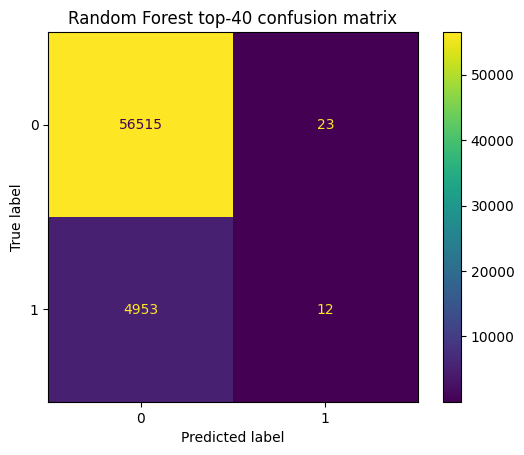

In [45]:
rf_40 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')
rf_40.fit(X_train_selected, y_train)
y_val_pred_rf40 = rf_40.predict(X_val_selected)
y_val_prob_rf40 = rf_40.predict_proba(X_val_selected)[:,1]
print('RF top40:', accuracy_score(y_val,y_val_pred_rf40), precision_score(y_val,y_val_pred_rf40), recall_score(y_val,y_val_pred_rf40), f1_score(y_val,y_val_pred_rf40), roc_auc_score(y_val,y_val_prob_rf40))
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_rf40); plt.title('Random Forest top-40 confusion matrix'); plt.show()

Original Random Forest top-40 results: Accuracy **0.91909**, Precision **0.34286**, Recall **0.00242**, F1 **0.0048**, ROC-AUC **0.73321**. Its high accuracy came mostly from predicting the majority class; the original confusion matrix had only **12 true positives** and **4,953 false negatives**.

In [46]:
scaler_107 = StandardScaler()
X_train_scaled_107 = scaler_107.fit_transform(X_train)
X_val_scaled_107 = scaler_107.transform(X_val)
lr_107 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_107.fit(X_train_scaled_107, y_train)
y_val_pred_lr107 = lr_107.predict(X_val_scaled_107)
y_val_prob_lr107 = lr_107.predict_proba(X_val_scaled_107)[:,1]
print('LR 107 precision:', precision_score(y_val,y_val_pred_lr107))
print('LR 107 recall   :', recall_score(y_val,y_val_pred_lr107))
print('LR 107 F1       :', f1_score(y_val,y_val_pred_lr107))
print('LR 107 ROC-AUC  :', roc_auc_score(y_val,y_val_prob_lr107))

LR 107 precision: 0.16343316077217088
LR 107 recall   : 0.6803625377643504
LR 107 F1       : 0.26355621440274635
LR 107 ROC-AUC  : 0.7537753841430679


Original all-107 Logistic Regression: Precision **0.16343**, Recall **0.68036**, F1 **0.26356**, ROC-AUC **0.75378** — better AUC than the top-40 linear baseline.

## 17. LightGBM — 107-feature numeric path

In [47]:
import lightgbm as lgb

def clean_feature_names(df):
    out = df.copy()
    out.columns = [re.sub(r'[^A-Za-z0-9_]+','_',str(c)).strip('_') for c in out.columns]
    return out

X_train_lgb = clean_feature_names(X_train); X_val_lgb = clean_feature_names(X_val); X_test_lgb = clean_feature_names(numeric_test_107)
lgb_model = lgb.LGBMClassifier(n_estimators=1500, learning_rate=.03, num_leaves=31, max_depth=-1, subsample=.8, colsample_bytree=.8, reg_alpha=.1, reg_lambda=.1, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
lgb_model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb,y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)])

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6632
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.750469	valid_0's binary_logloss: 0.588953
[200]	valid_0's auc: 0.759608	valid_0's binary_logloss: 0.571712
[300]	valid_0's auc: 0.762615	valid_0's binary_logloss: 0.56251
[400]	valid_0's auc: 0.763501	valid_0's binary_logloss: 0.556098
[500]	valid_0's auc: 0.764037	valid_0's binary_logloss: 0.550467
[600]	valid_0's auc: 0.764283	valid_0's binary_loglos

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,1500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [48]:
y_val_prob_lgb = lgb_model.predict_proba(X_val_lgb)[:,1]
y_val_pred_lgb = (y_val_prob_lgb >= .5).astype(int)
print('ROC-AUC:', roc_auc_score(y_val,y_val_prob_lgb))
print('PR-AUC :', average_precision_score(y_val,y_val_prob_lgb))
print(confusion_matrix(y_val,y_val_pred_lgb))
print(classification_report(y_val,y_val_pred_lgb))

ROC-AUC: 0.7646779071883745
PR-AUC : 0.2544212443667838
[[41550 14988]
 [ 1661  3304]]
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.67      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503



Original LightGBM: best iteration **757**, ROC-AUC **0.764678**, PR-AUC **0.254421**. Confusion matrix: `[[41550,14988],[1661,3304]]`.

,feature,importance
28,EXT_SOURCE_3,1203
27,EXT_SOURCE_2,1153
6,AMT_CREDIT,1076
64,AGE_YEARS,1047
10,DAYS_EMPLOYED,881
7,AMT_ANNUITY,867
87,PREVIOUS_AVG_CREDIT,850
34,DAYS_LAST_PHONE_CHANGE,839
63,CREDIT_INCOME_RATIO,826
92,AVG_PAYMENT_DELAY,817


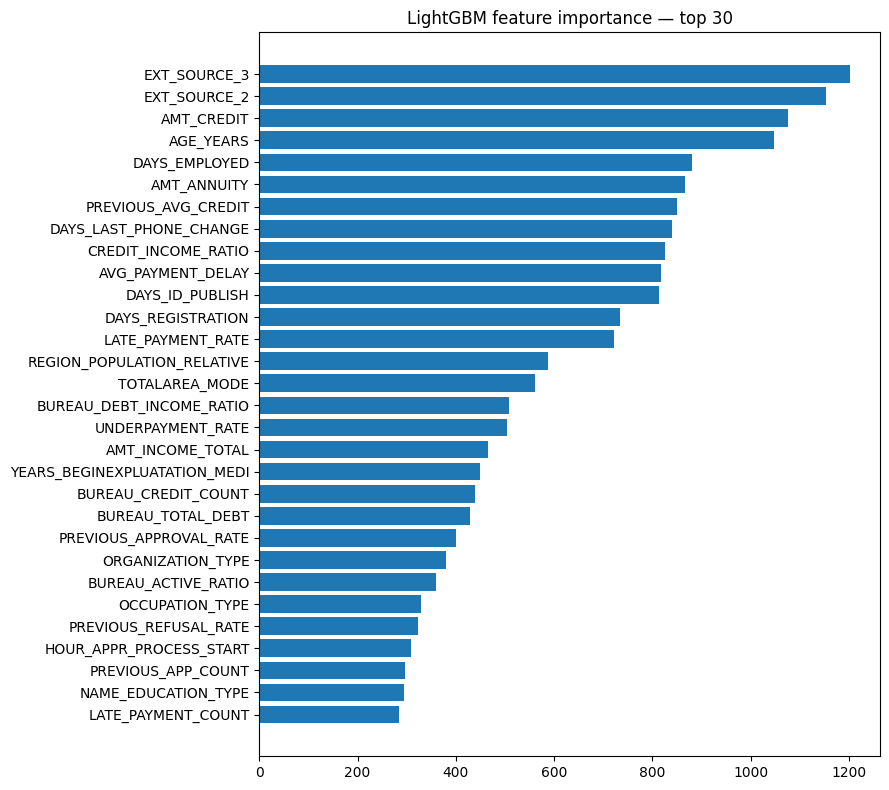

In [49]:
lgb_importance = pd.DataFrame({'feature':X_train_lgb.columns,'importance':lgb_model.feature_importances_}).sort_values('importance',ascending=False)
display(lgb_importance.head(30))
top = lgb_importance.head(30).sort_values('importance')
fig, ax = plt.subplots(figsize=(9,8)); ax.barh(top['feature'],top['importance']); ax.set_title('LightGBM feature importance — top 30'); plt.tight_layout(); plt.show()

## 18. CatBoost — preserve the 11 native categorical variables

In [50]:
cat_base = mapped_train.copy()
raw_categorical_cols = cat_base.select_dtypes(include=['object','category']).columns.tolist()
print('Raw categorical columns:', len(raw_categorical_cols), raw_categorical_cols)

encoded_cat_cols = [
'NAME_INCOME_TYPE_Pensioner','NAME_INCOME_TYPE_State servant','NAME_INCOME_TYPE_Working','NAME_INCOME_TYPE_Other',
'WALLSMATERIAL_MODE_Missing','WALLSMATERIAL_MODE_Mixed','WALLSMATERIAL_MODE_Monolithic','WALLSMATERIAL_MODE_Others','WALLSMATERIAL_MODE_Panel','WALLSMATERIAL_MODE_Stone, brick','WALLSMATERIAL_MODE_Wooden',
'EMERGENCYSTATE_MODE_No','EMERGENCYSTATE_MODE_Yes']
catboost_feature_cols = [c for c in X_train.columns if c not in encoded_cat_cols] + raw_categorical_cols
catboost_feature_cols = list(dict.fromkeys(catboost_feature_cols))

X_train_cat = cat_base.loc[X_train.index,catboost_feature_cols].copy()
X_val_cat = cat_base.loc[X_val.index,catboost_feature_cols].copy()
for c in raw_categorical_cols:
    X_train_cat[c] = X_train_cat[c].astype(str); X_val_cat[c] = X_val_cat[c].astype(str)
for c in X_train_cat.select_dtypes(include=['interval']).columns.tolist():
    cats = pd.Categorical(cat_base.loc[X_train.index,c]).categories
    X_train_cat[c] = pd.Categorical(X_train_cat[c], categories=cats, ordered=True).codes
    X_val_cat[c] = pd.Categorical(X_val_cat[c], categories=cats, ordered=True).codes
print('CatBoost train:', X_train_cat.shape, 'val:', X_val_cat.shape, 'categoricals:', len(raw_categorical_cols))

Raw categorical columns: 11 ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
CatBoost train: (246008, 103) val: (61503, 103) categoricals: 11


In [51]:
from catboost import CatBoostClassifier
catboost_model = CatBoostClassifier(iterations=3000, learning_rate=.03, depth=8, loss_function='Logloss', eval_metric='AUC', auto_class_weights='Balanced', random_seed=RANDOM_STATE, task_type='GPU' if USE_GPU else 'CPU', verbose=200, early_stopping_rounds=150)
catboost_model.fit(X_train_cat, y_train, cat_features=raw_categorical_cols, eval_set=(X_val_cat,y_val))
y_val_prob_cat = catboost_model.predict_proba(X_val_cat)[:,1]
print('CatBoost ROC-AUC:', roc_auc_score(y_val,y_val_prob_cat))
print('CatBoost PR-AUC :', average_precision_score(y_val,y_val_prob_cat))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7178254	best: 0.7178254 (0)	total: 107ms	remaining: 5m 20s
200:	test: 0.7599640	best: 0.7599640 (200)	total: 10.8s	remaining: 2m 29s
400:	test: 0.7640935	best: 0.7641211 (399)	total: 21.4s	remaining: 2m 18s
600:	test: 0.7652464	best: 0.7652811 (595)	total: 31.6s	remaining: 2m 5s
800:	test: 0.7650712	best: 0.7653651 (706)	total: 41.7s	remaining: 1m 54s
bestTest = 0.7653651237
bestIteration = 706
Shrink model to first 707 iterations.
CatBoost ROC-AUC: 0.7653651651980932
CatBoost PR-AUC : 0.2578498419461024


Original CatBoost: **103 features**, **11 categorical**, best iteration **706**, ROC-AUC **0.765365**, PR-AUC **0.257852**. It was the best individual recorded model. The source project did not finish a reliable `X_test_cat`, which is why the final submission stayed LightGBM-only.

## 19. XGBoost — 107-feature numeric path

In [52]:
from xgboost import XGBClassifier
scale_pos = (y_train==0).sum() / (y_train==1).sum()
xgb_model = XGBClassifier(n_estimators=2000, learning_rate=.03, max_depth=8, min_child_weight=5, subsample=.85, colsample_bytree=.85, gamma=.1, reg_alpha=.1, reg_lambda=1.0, scale_pos_weight=scale_pos, tree_method='hist', device='cuda' if USE_GPU else 'cpu', eval_metric='auc', early_stopping_rounds=100, random_state=RANDOM_STATE, n_jobs=-1)
xgb_model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb,y_val)], verbose=200)
y_val_prob_xgb = xgb_model.predict_proba(X_val_lgb)[:,1]
print('XGBoost ROC-AUC:', roc_auc_score(y_val,y_val_prob_xgb))
print('XGBoost PR-AUC :', average_precision_score(y_val,y_val_prob_xgb))
print('XGB vs LGB corr:', np.corrcoef(y_val_prob_xgb,y_val_prob_lgb)[0,1])
print('XGB vs CAT corr:', np.corrcoef(y_val_prob_xgb,y_val_prob_cat)[0,1])

[0]	validation_0-auc:0.71563
[200]	validation_0-auc:0.75871
[400]	validation_0-auc:0.76078
[545]	validation_0-auc:0.76014
XGBoost ROC-AUC: 0.7608870997189033
XGBoost PR-AUC : 0.24947322914576298
XGB vs LGB corr: 0.9661831037075644
XGB vs CAT corr: 0.9580953467926783


Original XGBoost: ROC-AUC **0.760887**, PR-AUC **0.249473**. Prediction correlation was **0.96618** with LightGBM and **0.95810** with CatBoost.

## 20. Model summary visualizations

In [53]:
model_summary = pd.DataFrame([
['LR top 40',roc_auc_score(y_val,y_val_prob_lr40),average_precision_score(y_val,y_val_prob_lr40)],
['RF top 40',roc_auc_score(y_val,y_val_prob_rf40),average_precision_score(y_val,y_val_prob_rf40)],
['LR 107',roc_auc_score(y_val,y_val_prob_lr107),average_precision_score(y_val,y_val_prob_lr107)],
['LightGBM',roc_auc_score(y_val,y_val_prob_lgb),average_precision_score(y_val,y_val_prob_lgb)],
['CatBoost',roc_auc_score(y_val,y_val_prob_cat),average_precision_score(y_val,y_val_prob_cat)],
['XGBoost',roc_auc_score(y_val,y_val_prob_xgb),average_precision_score(y_val,y_val_prob_xgb)],
], columns=['Model','ROC_AUC','PR_AUC']).sort_values('ROC_AUC',ascending=False)
display(model_summary)

,Model,ROC_AUC,PR_AUC
4,CatBoost,0.765365,0.257850
3,LightGBM,0.764678,0.254421
5,XGBoost,0.760887,0.249473
2,LR 107,0.753775,0.238439
0,LR top 40,0.741752,0.219607
1,RF top 40,0.733209,0.212263


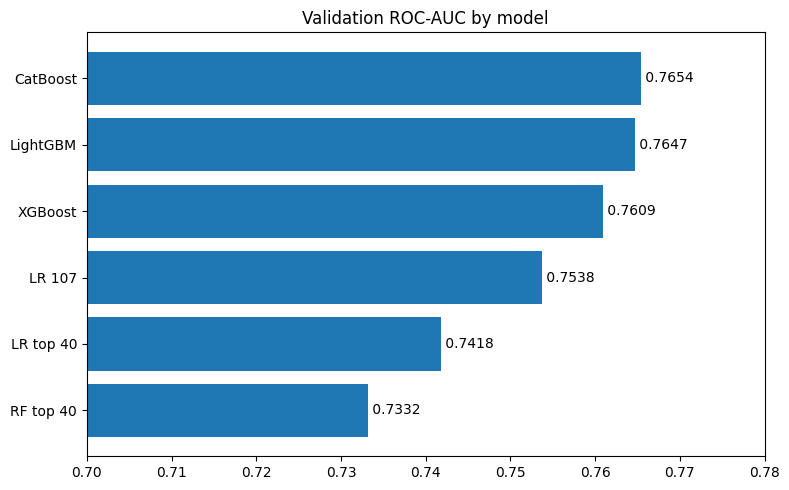

In [54]:
p = model_summary.sort_values('ROC_AUC')
fig, ax = plt.subplots(figsize=(8,5)); ax.barh(p['Model'],p['ROC_AUC']); ax.set_title('Validation ROC-AUC by model'); ax.set_xlim(.70,.78)
for i,v in enumerate(p['ROC_AUC']): ax.text(v,i,f' {v:.4f}',va='center')
plt.tight_layout(); plt.show()

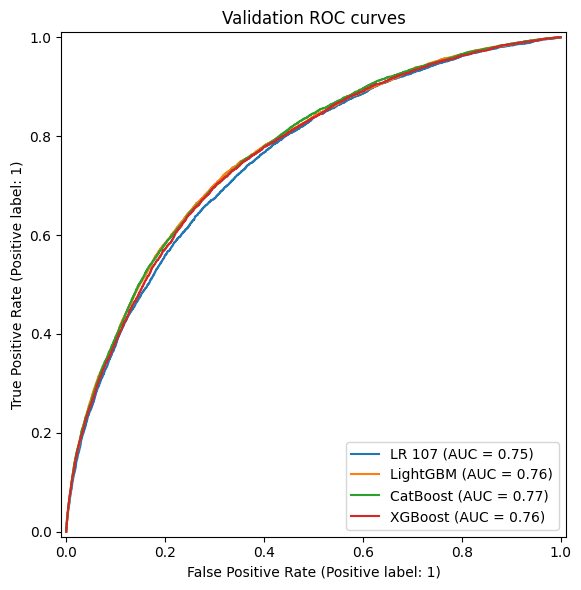

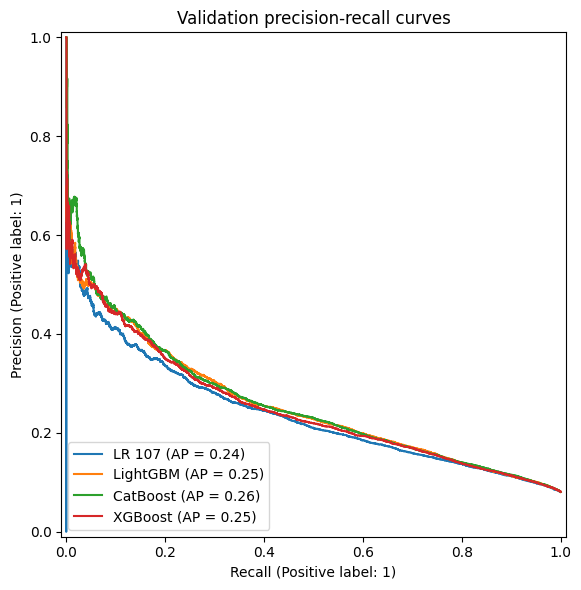

In [55]:
fig, ax = plt.subplots(figsize=(7,6))
for yprob,name in [(y_val_prob_lr107,'LR 107'),(y_val_prob_lgb,'LightGBM'),(y_val_prob_cat,'CatBoost'),(y_val_prob_xgb,'XGBoost')]:
    RocCurveDisplay.from_predictions(y_val,yprob,name=name,ax=ax)
ax.set_title('Validation ROC curves'); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7,6))
for yprob,name in [(y_val_prob_lr107,'LR 107'),(y_val_prob_lgb,'LightGBM'),(y_val_prob_cat,'CatBoost'),(y_val_prob_xgb,'XGBoost')]:
    PrecisionRecallDisplay.from_predictions(y_val,yprob,name=name,ax=ax)
ax.set_title('Validation precision-recall curves'); plt.tight_layout(); plt.show()

## 21. Ensemble experiments

In [56]:
blend2=[]
for w_cat in [.10,.25,.50,.75,.90]:
    pred = w_cat*y_val_prob_cat + (1-w_cat)*y_val_prob_lgb
    blend2.append([w_cat,1-w_cat,roc_auc_score(y_val,pred),average_precision_score(y_val,pred)])
display(pd.DataFrame(blend2,columns=['CatBoost weight','LightGBM weight','ROC_AUC','PR_AUC']))

,CatBoost weight,LightGBM weight,ROC_AUC,PR_AUC
0,0.10,0.90,0.765394,0.255896
1,0.25,0.75,0.766210,0.257711
2,0.50,0.50,0.766861,0.259232
3,0.75,0.25,0.766584,0.259269
4,0.90,0.10,0.765960,0.258617


In [57]:
blend3=[]
for w_lgb in [.2,.3,.4,.5]:
    for w_cat in [.3,.4,.5]:
        w_xgb = 1-w_lgb-w_cat
        if w_xgb < 0: continue
        pred = w_lgb*y_val_prob_lgb + w_cat*y_val_prob_cat + w_xgb*y_val_prob_xgb
        blend3.append([w_lgb,w_cat,w_xgb,roc_auc_score(y_val,pred),average_precision_score(y_val,pred)])
blend3 = pd.DataFrame(blend3,columns=['LightGBM','CatBoost','XGBoost','ROC_AUC','PR_AUC'])
display(blend3.sort_values('ROC_AUC',ascending=False).head(10))

,LightGBM,CatBoost,XGBoost,ROC_AUC,PR_AUC
8,0.4,0.5,0.1,0.766916,0.259274
11,0.5,0.5,0.0,0.766861,0.259232
10,0.5,0.4,0.1,0.766821,0.258932
5,0.3,0.5,0.2,0.766815,0.259027
7,0.4,0.4,0.2,0.766776,0.258722
9,0.5,0.3,0.2,0.766586,0.258201
4,0.3,0.4,0.3,0.766575,0.258285
2,0.2,0.5,0.3,0.766556,0.258473
6,0.4,0.3,0.3,0.766446,0.257811
1,0.2,0.4,0.4,0.766205,0.257547


Best recorded blend: **0.4 LightGBM + 0.5 CatBoost + 0.1 XGBoost**, ROC-AUC **0.766916**, PR-AUC **0.259271**. This slightly beat the individual models, but the implemented submission remained LightGBM-only.

## 22. Additional LightGBM checks from the second notebook

In [58]:
lgb_model_63 = lgb.LGBMClassifier(n_estimators=2000,learning_rate=.03,num_leaves=63,max_depth=-1,subsample=.8,colsample_bytree=.8,reg_alpha=.1,reg_lambda=.1,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1)
lgb_model_63.fit(X_train_lgb,y_train,eval_set=[(X_val_lgb,y_val)],eval_metric='auc',callbacks=[lgb.early_stopping(100),lgb.log_evaluation(200)])
print('num_leaves=63 ROC-AUC:', roc_auc_score(y_val,lgb_model_63.predict_proba(X_val_lgb)[:,1]))

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6632
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.760721	valid_0's binary_logloss: 0.556064
[400]	valid_0's auc: 0.76336	valid_0's binary_logloss: 0.531357
Early stopping, best iteration is:
[496]	valid_0's auc: 0.763842	valid_0's binary_logloss: 0.5217
num_leaves=63 ROC-AUC: 0.7638419803529728


In [59]:
lgb_unweighted = lgb.LGBMClassifier(n_estimators=1500,learning_rate=.03,num_leaves=31,max_depth=-1,subsample=.8,colsample_bytree=.8,reg_alpha=.1,reg_lambda=.1,random_state=RANDOM_STATE,n_jobs=-1)
lgb_unweighted.fit(X_train_lgb,y_train,eval_set=[(X_val_lgb,y_val)],eval_metric='auc',callbacks=[lgb.early_stopping(100),lgb.log_evaluation(200)])
print('Unweighted ROC-AUC:', roc_auc_score(y_val,lgb_unweighted.predict_proba(X_val_lgb)[:,1]))

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6632
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.757838	valid_0's binary_logloss: 0.245827
[400]	valid_0's auc: 0.761817	valid_0's binary_logloss: 0.244432
[600]	valid_0's auc: 0.762922	valid_0's binary_logloss: 0.244065
[800]	valid_0's auc: 0.763682	valid_0's binary_logloss: 0.243878
Early stopping, best iteration is:
[876]	valid_0's auc: 0.763984	valid_0's binary_logloss: 0.243799
Unweighted ROC-AU

Recorded results: `num_leaves=63` **0.763842**, unweighted LightGBM **0.763984**, both below the baseline balanced LightGBM **0.764678**.

## 23. Final LightGBM submission

In [60]:
X_test_lgb = clean_feature_names(numeric_test_107.copy())
X_test_lgb = X_test_lgb[X_train_lgb.columns]
assert X_test_lgb.columns.equals(X_train_lgb.columns)
predictions = lgb_model.predict_proba(X_test_lgb)[:,1]
submission = pd.DataFrame({'SK_ID_CURR':sample_submission['SK_ID_CURR'].values,'TARGET':predictions})
assert submission.shape == (48744,2)
assert submission['SK_ID_CURR'].duplicated().sum() == 0
assert submission.isna().sum().sum() == 0
assert submission['TARGET'].between(0,1).all()
submission_path = DATA_PATH / 'submission.csv'
submission.to_csv(submission_path,index=False)
print('Saved:', submission_path)
display(submission.head(10)); display(submission['TARGET'].describe())

Saved: C:\Mim\6th trimester\Data Analytics\Main project\home-credit-default-risk\submission.csv


,SK_ID_CURR,TARGET
0,100001,0.325977
1,100005,0.748586
2,100013,0.108002
3,100028,0.289502
4,100038,0.618426
5,100042,0.302562
6,100057,0.193885
7,100065,0.296150
8,100066,0.093861
9,100067,0.456322


count    48744.000000
mean         0.380393
std          0.202096
min          0.014075
25%          0.213037
50%          0.350149
75%          0.530558
max          0.939109
Name: TARGET, dtype: float64

The source notebook's LightGBM-only submission had prediction mean **0.319657**, std **0.193920**, min **0.008469**, max **0.921318**. Because this organized notebook makes some test-side definitions consistent with training, your rerun may produce slightly different test probabilities while keeping the same modeling design.

## 24. Export feature/model summaries

In [61]:
feature_importance.to_csv(PROCESSED_PATH/'rf_feature_importance.csv',index=False)
lgb_importance.to_csv(PROCESSED_PATH/'lgb_feature_importance.csv',index=False)
model_summary.to_csv(PROCESSED_PATH/'model_summary.csv',index=False)
feature_lineage.to_csv(PROCESSED_PATH/'engineered_feature_lineage.csv',index=False)
print('Summary files written to', PROCESSED_PATH)

Summary files written to C:\Mim\6th trimester\Data Analytics\Main project\home-credit-default-risk\processed


# Final flow

Raw current application data  
→ 5 application-level features  
→ bureau applicant history  
→ bureau-balance monthly history  
→ previous-application history  
→ installment-payment behavior  
→ **40 added features**  
→ categorical missing = `Missing`  
→ remove **38** >50%-missing numerical columns  
→ median imputation  
→ IQR **outlier detection**  
→ remove 4 redundant housing variables  
→ shared binary/ordinal mappings  
→ **two branches**:

**Numeric branch:** frequency encoding → Cramér's V / chi-square screening → one-hot encoding → 122 predictors → remove 15 redundant variables → **107 predictors** → LR / RF / LightGBM / XGBoost.

**CatBoost branch:** preserve 11 native categorical variables → rebuild from raw mapped table → **103 predictors** → CatBoost.

Random-Forest importance was also used to produce a **top-40 baseline subset**.

Best recorded individual model: **CatBoost 0.765365 ROC-AUC**.  
Best recorded tested blend: **0.766916 ROC-AUC**.  
Actual project submission path: **LightGBM**.

In [62]:
# ================================================================
# ADD CATBOOST + LIGHTGBM TO DEPLOYMENT EXPORT
# ================================================================

import os
import json
import joblib

BASE_DIR = "model"
CLASSIFICATION_THRESHOLD = 0.50

os.makedirs(BASE_DIR, exist_ok=True)

assert 0 <= CLASSIFICATION_THRESHOLD <= 1


# ================================================================
# HELPER
# ================================================================

def save_json(data, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)


def show_export(folder, model_file):

    model_path = os.path.join(
        BASE_DIR,
        folder,
        model_file
    )

    size_mb = os.path.getsize(
        model_path
    ) / (1024 * 1024)

    print("\n" + "=" * 60)
    print(folder.upper())
    print("=" * 60)

    print("Model file :", model_file)
    print(f"Model size : {size_mb:.2f} MB")
    print("Threshold  :", CLASSIFICATION_THRESHOLD)

    if size_mb <= 100:
        print("Size check : PASS")
    else:
        print("Size check : FAILED (>100 MB)")


# ================================================================
# 1. LIGHTGBM
# ================================================================

lgb_dir = os.path.join(
    BASE_DIR,
    "lightgbm"
)

os.makedirs(
    lgb_dir,
    exist_ok=True
)


# ------------------------------------------------
# Feature order
# ------------------------------------------------

lgb_features = [
    str(col)
    for col in X_train_lgb.columns
]


# ------------------------------------------------
# Save native LightGBM model
# ------------------------------------------------

lgb_model_path = os.path.join(
    lgb_dir,
    "model.txt"
)

lgb_model.booster_.save_model(
    lgb_model_path
)


# ------------------------------------------------
# Also save sklearn wrapper
# Optional but useful
# ------------------------------------------------

joblib.dump(
    lgb_model,
    os.path.join(
        lgb_dir,
        "model.pkl"
    )
)


# ------------------------------------------------
# Feature columns
# ------------------------------------------------

save_json(
    lgb_features,
    os.path.join(
        lgb_dir,
        "feature_columns.json"
    )
)


# ------------------------------------------------
# Metadata
# ------------------------------------------------

lgb_metadata = {

    "model_name":
        "lightgbm",

    "model_type":
        "LightGBM Classifier",

    "framework":
        "lightgbm",

    "task":
        "binary_classification",

    "target":
        "TARGET",

    "classification_threshold":
        float(CLASSIFICATION_THRESHOLD),

    "threshold":
        float(CLASSIFICATION_THRESHOLD),

    "positive_class":
        1,

    "negative_class":
        0,

    "prediction_type":
        "probability",

    "feature_count":
        len(lgb_features),

    "feature_order":
        lgb_features,

    "feature_columns_file":
        "feature_columns.json",

    "model_file":
        "model.txt",

    "alternative_model_file":
        "model.pkl",

    "requires_preprocessing":
        False,

    "preprocessor_file":
        None,

    "smote_used_during_training":
        False,

    "apply_smote_during_inference":
        False
}


save_json(
    lgb_metadata,
    os.path.join(
        lgb_dir,
        "metadata.json"
    )
)


show_export(
    "lightgbm",
    "model.txt"
)


# ================================================================
# 2. CATBOOST
# ================================================================

cat_dir = os.path.join(
    BASE_DIR,
    "catboost"
)

os.makedirs(
    cat_dir,
    exist_ok=True
)


# ------------------------------------------------
# Feature order
# ------------------------------------------------

cat_features = [
    str(col)
    for col in X_train_cat.columns
]


# ------------------------------------------------
# Save native CatBoost model
# ------------------------------------------------

cat_model_path = os.path.join(
    cat_dir,
    "model.cbm"
)

catboost_model.save_model(
    cat_model_path,
    format="cbm"
)


# ------------------------------------------------
# Also save Python model
# ------------------------------------------------

joblib.dump(
    catboost_model,
    os.path.join(
        cat_dir,
        "model.pkl"
    )
)


# ------------------------------------------------
# Feature columns
# ------------------------------------------------

save_json(
    cat_features,
    os.path.join(
        cat_dir,
        "feature_columns.json"
    )
)


# ------------------------------------------------
# Categorical feature names
# ------------------------------------------------

if "raw_categorical_cols" in globals():

    cat_categorical_features = [
        str(col)
        for col in raw_categorical_cols
        if col in cat_features
    ]

else:

    cat_categorical_features = []


save_json(
    cat_categorical_features,
    os.path.join(
        cat_dir,
        "categorical_features.json"
    )
)


# ------------------------------------------------
# Categorical feature indices
# ------------------------------------------------

cat_feature_indices = [
    cat_features.index(col)
    for col in cat_categorical_features
]


save_json(
    cat_feature_indices,
    os.path.join(
        cat_dir,
        "categorical_feature_indices.json"
    )
)


# ------------------------------------------------
# Metadata
# ------------------------------------------------

cat_metadata = {

    "model_name":
        "catboost",

    "model_type":
        "CatBoost Classifier",

    "framework":
        "catboost",

    "task":
        "binary_classification",

    "target":
        "TARGET",

    "classification_threshold":
        float(CLASSIFICATION_THRESHOLD),

    "threshold":
        float(CLASSIFICATION_THRESHOLD),

    "positive_class":
        1,

    "negative_class":
        0,

    "prediction_type":
        "probability",

    "feature_count":
        len(cat_features),

    "feature_order":
        cat_features,

    "feature_columns_file":
        "feature_columns.json",

    "categorical_features_file":
        "categorical_features.json",

    "categorical_feature_indices_file":
        "categorical_feature_indices.json",

    "categorical_features":
        cat_categorical_features,

    "model_file":
        "model.cbm",

    "alternative_model_file":
        "model.pkl",

    "requires_preprocessing":
        False,

    "preprocessor_file":
        None,

    "smote_used_during_training":
        False,

    "apply_smote_during_inference":
        False
}


save_json(
    cat_metadata,
    os.path.join(
        cat_dir,
        "metadata.json"
    )
)


show_export(
    "catboost",
    "model.cbm"
)


# ================================================================
# 3. VALIDATE BOTH DEPLOYMENT PACKAGES
# ================================================================

print("\n")
print("=" * 70)
print("VALIDATING CATBOOST + LIGHTGBM EXPORTS")
print("=" * 70)


for folder_name in [
    "lightgbm",
    "catboost"
]:

    folder = os.path.join(
        BASE_DIR,
        folder_name
    )

    metadata_path = os.path.join(
        folder,
        "metadata.json"
    )

    feature_path = os.path.join(
        folder,
        "feature_columns.json"
    )


    # ------------------------------------------
    # Metadata
    # ------------------------------------------

    with open(
        metadata_path,
        "r",
        encoding="utf-8"
    ) as f:

        metadata = json.load(f)


    threshold = metadata.get(
        "classification_threshold"
    )


    assert threshold is not None, (
        f"{folder_name}: "
        "classification_threshold missing"
    )

    assert 0 <= threshold <= 1, (
        f"{folder_name}: "
        "invalid classification threshold"
    )


    # ------------------------------------------
    # Feature columns
    # ------------------------------------------

    with open(
        feature_path,
        "r",
        encoding="utf-8"
    ) as f:

        features = json.load(f)


    assert isinstance(
        features,
        list
    )

    assert len(features) == metadata[
        "feature_count"
    ]


    # ------------------------------------------
    # Model exists
    # ------------------------------------------

    model_path = os.path.join(
        folder,
        metadata["model_file"]
    )

    assert os.path.exists(
        model_path
    )


    model_size = os.path.getsize(
        model_path
    ) / (1024 * 1024)


    assert model_size <= 100, (
        f"{folder_name} model exceeds "
        "100 MB deployment limit."
    )


    print(
        f"\n✓ {folder_name}"
    )

    print(
        "  Model:",
        metadata["model_file"]
    )

    print(
        "  Features:",
        len(features)
    )

    print(
        "  Threshold:",
        threshold
    )

    print(
        f"  Size: {model_size:.2f} MB"
    )


print("\n" + "=" * 70)
print("CATBOOST + LIGHTGBM EXPORT COMPLETE")
print("=" * 70)


LIGHTGBM
Model file : model.txt
Model size : 2.55 MB
Threshold  : 0.5
Size check : PASS

CATBOOST
Model file : model.cbm
Model size : 3.04 MB
Threshold  : 0.5
Size check : PASS


VALIDATING CATBOOST + LIGHTGBM EXPORTS

✓ lightgbm
  Model: model.txt
  Features: 107
  Threshold: 0.5
  Size: 2.55 MB

✓ catboost
  Model: model.cbm
  Features: 103
  Threshold: 0.5
  Size: 3.04 MB

CATBOOST + LIGHTGBM EXPORT COMPLETE


MLP pipline + model saving

In [63]:

# CreditScope - MLP PIPELINE TRAIN + SAVE
# Saves everything to: /model/mlp/
# ============================================================

from pathlib import Path
import json
import inspect
import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve
)

# ------------------------------------------------------------
# 1. Output folder
# ------------------------------------------------------------
MODEL_DIR = Path(DATA_PATH) / "model" / "mlp"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Saving MLP files to:")
print(MODEL_DIR)


# ------------------------------------------------------------
# 2. Use the existing 107-feature split from the notebook
# ------------------------------------------------------------
X_train_mlp = X_train.copy()
X_val_mlp = X_val.copy()

y_train_mlp = pd.Series(y_train).copy()
y_val_mlp = pd.Series(y_val).copy()

feature_columns = X_train_mlp.columns.tolist()

print("Train shape:", X_train_mlp.shape)
print("Val shape  :", X_val_mlp.shape)
print("Features   :", len(feature_columns))


# ------------------------------------------------------------
# 3. Full MLP pipeline
# ------------------------------------------------------------
mlp_pipeline = Pipeline([
    
    # safety in case a future prediction contains numeric NaNs
    ("imputer", SimpleImputer(strategy="median")),
    
    # MLP benefits heavily from scaling
    ("scaler", StandardScaler()),
    
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",

        alpha=1e-4,
        learning_rate_init=0.001,
        batch_size=1024,

        max_iter=100,

        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,

        random_state=RANDOM_STATE,
        verbose=True
    ))
])


# ------------------------------------------------------------
# 4. Handle class imbalance when supported
# ------------------------------------------------------------
supports_sample_weight = (
    "sample_weight"
    in inspect.signature(MLPClassifier.fit).parameters
)

if supports_sample_weight:

    train_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train_mlp
    )

    mlp_pipeline.fit(
        X_train_mlp,
        y_train_mlp,
        mlp__sample_weight=train_weights
    )

    balancing_method = "balanced sample weights"

else:

    print(
        "This sklearn version does not support "
        "sample_weight for MLPClassifier."
    )

    mlp_pipeline.fit(
        X_train_mlp,
        y_train_mlp
    )

    balancing_method = "unweighted"


# ------------------------------------------------------------
# 5. Validation probabilities
# ------------------------------------------------------------
y_val_prob_mlp = mlp_pipeline.predict_proba(
    X_val_mlp
)[:, 1]


# ------------------------------------------------------------
# 6. Find best F1 threshold
# ------------------------------------------------------------
precision_curve, recall_curve, thresholds = (
    precision_recall_curve(
        y_val_mlp,
        y_val_prob_mlp
    )
)

denominator = (
    precision_curve[:-1]
    + recall_curve[:-1]
)

f1_curve = np.divide(
    2 * precision_curve[:-1] * recall_curve[:-1],
    denominator,
    out=np.zeros_like(denominator),
    where=denominator != 0
)

best_index = np.argmax(f1_curve)

best_threshold = float(
    thresholds[best_index]
)

y_val_pred_mlp = (
    y_val_prob_mlp >= best_threshold
).astype(int)


# ------------------------------------------------------------
# 7. Evaluation
# ------------------------------------------------------------
metrics = {

    "threshold":
        best_threshold,

    "accuracy":
        accuracy_score(
            y_val_mlp,
            y_val_pred_mlp
        ),

    "balanced_accuracy":
        balanced_accuracy_score(
            y_val_mlp,
            y_val_pred_mlp
        ),

    "precision":
        precision_score(
            y_val_mlp,
            y_val_pred_mlp,
            zero_division=0
        ),

    "recall":
        recall_score(
            y_val_mlp,
            y_val_pred_mlp,
            zero_division=0
        ),

    "f1":
        f1_score(
            y_val_mlp,
            y_val_pred_mlp,
            zero_division=0
        ),

    "roc_auc":
        roc_auc_score(
            y_val_mlp,
            y_val_prob_mlp
        ),

    "pr_auc":
        average_precision_score(
            y_val_mlp,
            y_val_prob_mlp
        ),

    "confusion_matrix":
        confusion_matrix(
            y_val_mlp,
            y_val_pred_mlp
        ).tolist()
}


print("\n========== MLP RESULTS ==========")

for key, value in metrics.items():
    print(f"{key}: {value}")


# ------------------------------------------------------------
# 8. Save complete pipeline
# ------------------------------------------------------------
MODEL_FILE = (
    MODEL_DIR
    / "mlp_pipeline.joblib"
)

joblib.dump(
    mlp_pipeline,
    MODEL_FILE,
    compress=3
)


# ------------------------------------------------------------
# 9. Save metadata
# ------------------------------------------------------------
metadata = {

    "project":
        "CreditScope",

    "model":
        "MLPClassifier",

    "architecture":
        [128, 64, 32],

    "pipeline": [
        "Median Imputer",
        "StandardScaler",
        "MLPClassifier"
    ],

    "number_of_features":
        len(feature_columns),

    "feature_columns":
        feature_columns,

    "class_balancing":
        balancing_method,

    "recommended_threshold":
        best_threshold,

    "validation_metrics":
        metrics,

    "random_state":
        RANDOM_STATE,

    "versions": {
        "scikit_learn":
            sklearn.__version__,

        "numpy":
            np.__version__,

        "pandas":
            pd.__version__,

        "joblib":
            joblib.__version__
    }
}


with open(
    MODEL_DIR / "metadata.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ------------------------------------------------------------
# 10. Save feature list separately
# ------------------------------------------------------------
with open(
    MODEL_DIR / "feature_columns.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        feature_columns,
        f,
        indent=4
    )


# ------------------------------------------------------------
# 11. Save requirements
# ------------------------------------------------------------
with open(
    MODEL_DIR / "requirements.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(
        f"scikit-learn=={sklearn.__version__}\n"
        f"numpy=={np.__version__}\n"
        f"pandas=={pd.__version__}\n"
        f"joblib=={joblib.__version__}\n"
    )


# ------------------------------------------------------------
# 12. Verify
# ------------------------------------------------------------
print("\n========== SAVED FILES ==========")

for file in MODEL_DIR.iterdir():
    print(file.name)

print("\nMain shareable model:")
print(MODEL_FILE)

print("\n✅ MLP pipeline saved successfully.")


Saving MLP files to:
C:\Mim\6th trimester\Data Analytics\Main project\home-credit-default-risk\model\mlp
Train shape: (246008, 107)
Val shape  : (61503, 107)
Features   : 107
Iteration 1, loss = 0.61421214
Validation score: 0.673453
Iteration 2, loss = 0.58983226
Validation score: 0.675964
Iteration 3, loss = 0.58252503
Validation score: 0.681241
Iteration 4, loss = 0.57634150
Validation score: 0.680081
Iteration 5, loss = 0.57053624
Validation score: 0.681402
Iteration 6, loss = 0.56551567
Validation score: 0.679401
Iteration 7, loss = 0.56053702
Validation score: 0.680132
Iteration 8, loss = 0.55432460
Validation score: 0.677490
Iteration 9, loss = 0.54879105
Validation score: 0.672822
Iteration 10, loss = 0.54288760
Validation score: 0.675851
Iteration 11, loss = 0.53643032
Validation score: 0.670638
Iteration 12, loss = 0.52937937
Validation score: 0.666325
Iteration 13, loss = 0.52294418
Validation score: 0.666847
Iteration 14, loss = 0.51640668
Validation score: 0.670528
Iteratio

In [64]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4060


In [65]:
# ============================================================
# CreditScope - PyTorch DCN TRAIN + SAVE
# Uses GPU automatically
# Saves to: /model/dcn/credit_dcn.pth
# ============================================================

from pathlib import Path
import copy
import numpy as np
import pandas as pd
import joblib

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# 2. Output folder
# ------------------------------------------------------------
MODEL_DIR = Path(DATA_PATH) / "model" / "dcn"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = MODEL_DIR / "credit_dcn.pth"

print("Model will be saved to:")
print(MODEL_FILE)


# ------------------------------------------------------------
# 3. Existing 107-feature data
# ------------------------------------------------------------
X_train_dcn = X_train.copy()
X_val_dcn = X_val.copy()

y_train_dcn = np.asarray(y_train).astype(np.float32)
y_val_dcn = np.asarray(y_val).astype(np.float32)

feature_columns = X_train_dcn.columns.tolist()

print("\nTrain:", X_train_dcn.shape)
print("Val  :", X_val_dcn.shape)
print("Features:", len(feature_columns))


# ------------------------------------------------------------
# 4. Impute + Scale
# ------------------------------------------------------------
imputer = SimpleImputer(strategy="median")

X_train_dcn = imputer.fit_transform(X_train_dcn)
X_val_dcn = imputer.transform(X_val_dcn)

scaler = StandardScaler()

X_train_dcn = scaler.fit_transform(X_train_dcn)
X_val_dcn = scaler.transform(X_val_dcn)


# ------------------------------------------------------------
# 5. Convert to PyTorch tensors
# ------------------------------------------------------------
X_train_tensor = torch.tensor(
    X_train_dcn,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_dcn,
    dtype=torch.float32
).view(-1, 1)

X_val_tensor = torch.tensor(
    X_val_dcn,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_dcn,
    dtype=torch.float32
).view(-1, 1)


train_loader = DataLoader(
    TensorDataset(
        X_train_tensor,
        y_train_tensor
    ),
    batch_size=2048,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    TensorDataset(
        X_val_tensor,
        y_val_tensor
    ),
    batch_size=4096,
    shuffle=False,
    pin_memory=True
)


# ------------------------------------------------------------
# 6. Cross layer
# ------------------------------------------------------------
class CrossLayer(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(input_dim) * 0.01
        )

        self.bias = nn.Parameter(
            torch.zeros(input_dim)
        )

    def forward(self, x0, x):

        xw = torch.sum(
            x * self.weight,
            dim=1,
            keepdim=True
        )

        return x0 * xw + self.bias + x


# ------------------------------------------------------------
# 7. Deep & Cross Network
# ------------------------------------------------------------
class DeepCrossNetwork(nn.Module):

    def __init__(
        self,
        input_dim,
        cross_layers=3
    ):
        super().__init__()

        self.cross_layers = nn.ModuleList([
            CrossLayer(input_dim)
            for _ in range(cross_layers)
        ])

        self.deep = nn.Sequential(

            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.output = nn.Linear(
            input_dim + 64,
            1
        )


    def forward(self, x):

        x0 = x
        cross = x

        for layer in self.cross_layers:
            cross = layer(x0, cross)

        deep = self.deep(x)

        combined = torch.cat(
            [cross, deep],
            dim=1
        )

        return self.output(combined)


# ------------------------------------------------------------
# 8. Create model
# ------------------------------------------------------------
input_dim = X_train_tensor.shape[1]

dcn_model = DeepCrossNetwork(
    input_dim=input_dim,
    cross_layers=3
).to(device)

print("\nModel:")
print(dcn_model)


# ------------------------------------------------------------
# 9. Handle class imbalance
# ------------------------------------------------------------
negative = np.sum(y_train_dcn == 0)
positive = np.sum(y_train_dcn == 1)

pos_weight = negative / positive

print("\nPositive class weight:", pos_weight)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        [pos_weight],
        dtype=torch.float32,
        device=device
    )
)


# ------------------------------------------------------------
# 10. Optimizer
# ------------------------------------------------------------
optimizer = torch.optim.AdamW(
    dcn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


# ------------------------------------------------------------
# 11. Training settings
# ------------------------------------------------------------
EPOCHS = 50
PATIENCE = 7

best_val_loss = float("inf")
best_state = None

patience_counter = 0


# ------------------------------------------------------------
# 12. Train
# ------------------------------------------------------------
for epoch in range(EPOCHS):

    # ========================
    # Training
    # ========================
    dcn_model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        logits = dcn_model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item()
            * X_batch.size(0)
        )


    train_loss /= len(train_loader.dataset)


    # ========================
    # Validation
    # ========================
    dcn_model.eval()

    val_loss = 0.0
    val_probs = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(
                device,
                non_blocking=True
            )

            y_batch = y_batch.to(
                device,
                non_blocking=True
            )

            logits = dcn_model(
                X_batch
            )

            loss = criterion(
                logits,
                y_batch
            )

            val_loss += (
                loss.item()
                * X_batch.size(0)
            )

            probabilities = torch.sigmoid(
                logits
            )

            val_probs.extend(
                probabilities
                .cpu()
                .numpy()
                .ravel()
            )


    val_loss /= len(val_loader.dataset)

    val_probs = np.array(
        val_probs
    )


    val_auc = roc_auc_score(
        y_val_dcn,
        val_probs
    )

    val_pr_auc = average_precision_score(
        y_val_dcn,
        val_probs
    )


    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"ROC-AUC: {val_auc:.4f} | "
        f"PR-AUC: {val_pr_auc:.4f}"
    )


    scheduler.step(
        val_loss
    )


    # ========================
    # Early stopping
    # ========================
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = copy.deepcopy(
            dcn_model.state_dict()
        )

        patience_counter = 0

    else:

        patience_counter += 1


    if patience_counter >= PATIENCE:

        print(
            "\nEarly stopping triggered."
        )

        break


# ------------------------------------------------------------
# 13. Restore best model
# ------------------------------------------------------------
dcn_model.load_state_dict(
    best_state
)

dcn_model.eval()


# ------------------------------------------------------------
# 14. Final validation probabilities
# ------------------------------------------------------------
final_probabilities = []

with torch.no_grad():

    for X_batch, _ in val_loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        logits = dcn_model(
            X_batch
        )

        probability = torch.sigmoid(
            logits
        )

        final_probabilities.extend(
            probability
            .cpu()
            .numpy()
            .ravel()
        )


y_val_prob_dcn = np.array(
    final_probabilities
)


# ------------------------------------------------------------
# 15. Best F1 threshold
# ------------------------------------------------------------
precision_curve, recall_curve, thresholds = (
    precision_recall_curve(
        y_val_dcn,
        y_val_prob_dcn
    )
)

denominator = (
    precision_curve[:-1]
    + recall_curve[:-1]
)

f1_curve = np.divide(

    2
    * precision_curve[:-1]
    * recall_curve[:-1],

    denominator,

    out=np.zeros_like(
        denominator
    ),

    where=denominator != 0
)

best_index = np.argmax(
    f1_curve
)

best_threshold = float(
    thresholds[best_index]
)

y_val_pred_dcn = (
    y_val_prob_dcn
    >= best_threshold
).astype(int)


# ------------------------------------------------------------
# 16. Evaluation
# ------------------------------------------------------------
print("\n========== DCN RESULTS ==========")

print(
    "Threshold:",
    best_threshold
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_dcn,
        y_val_pred_dcn
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val_dcn,
        y_val_pred_dcn
    )
)

print(
    "Precision:",
    precision_score(
        y_val_dcn,
        y_val_pred_dcn,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_val_dcn,
        y_val_pred_dcn,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_val_dcn,
        y_val_pred_dcn,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_val_dcn,
        y_val_prob_dcn
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val_dcn,
        y_val_prob_dcn
    )
)

print(
    "Confusion Matrix:\n",
    confusion_matrix(
        y_val_dcn,
        y_val_pred_dcn
    )
)


# ------------------------------------------------------------
# 17. Save model
# ------------------------------------------------------------
torch.save(
    {
        "model_state_dict":
            dcn_model.state_dict(),

        "input_dim":
            input_dim,

        "cross_layers":
            3,

        "feature_columns":
            feature_columns,

        "threshold":
            best_threshold
    },

    MODEL_FILE
)


# ------------------------------------------------------------
# 18. Save preprocessing
# ------------------------------------------------------------
joblib.dump(
    {
        "imputer": imputer,
        "scaler": scaler
    },

    MODEL_DIR / "preprocessor.joblib"
)


# ------------------------------------------------------------
# 19. Done
# ------------------------------------------------------------
print("\n==============================")
print("✅ DCN TRAINING COMPLETE")
print("==============================")

print("\nSaved model:")
print(MODEL_FILE)

print("\nSaved preprocessor:")
print(
    MODEL_DIR / "preprocessor.joblib"
)

Device: cuda
GPU: NVIDIA GeForce RTX 4060
Model will be saved to:
C:\Mim\6th trimester\Data Analytics\Main project\home-credit-default-risk\model\dcn\credit_dcn.pth

Train: (246008, 107)
Val  : (61503, 107)
Features: 107

Model:
DeepCrossNetwork(
  (cross_layers): ModuleList(
    (0-2): 3 x CrossLayer()
  )
  (deep): Sequential(
    (0): Linear(in_features=107, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=171, out_features=1, bias=True)
)

Positive class weight: 11.38710976837865
Epoch 01/50 | Train Loss: 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Before SMOTE:
TARGET
0    226148
1     19860
Name: count, dtype: int64

After SMOTE:
TARGET
0    226148
1    226148
Name: count, dtype: int64

Original training shape : (246008, 40)
After SMOTE shape       : (452296, 40)

LOGISTIC REGRESSION + SMOTE RESULTS
Accuracy  : 0.686048
Precision : 0.158216
Recall    : 0.668681
F1 Score  : 0.255887
ROC-AUC   : 0.739911
PR-AUC    : 0.217380

Confusion Matrix:
[[38874 17664]
 [ 1645  3320]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.89      0.69      0.76     61503



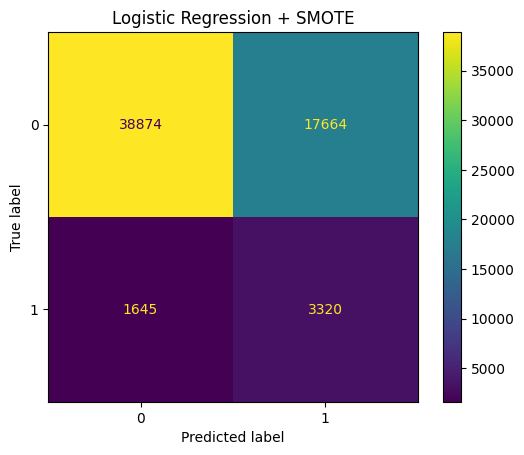

In [66]:
# ============================================================
# LOGISTIC REGRESSION + SMOTE
# Using Top-40 Selected Features
# ============================================================
%pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. SCALE DATA
# ------------------------------------------------------------

scaler_smote = StandardScaler()

X_train_scaled_smote = scaler_smote.fit_transform(X_train_selected)
X_val_scaled_smote = scaler_smote.transform(X_val_selected)

# ------------------------------------------------------------
# 2. APPLY SMOTE ONLY TO TRAINING DATA
# ------------------------------------------------------------

print("Before SMOTE:")
print(y_train.value_counts())
print()

smote = SMOTE(
    random_state=RANDOM_STATE
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled_smote,
    y_train
)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nOriginal training shape :", X_train_scaled_smote.shape)
print("After SMOTE shape       :", X_train_smote.shape)

# ------------------------------------------------------------
# 3. TRAIN LOGISTIC REGRESSION
# ------------------------------------------------------------

lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

# ------------------------------------------------------------
# 4. PREDICTIONS ON ORIGINAL VALIDATION SET
# ------------------------------------------------------------

y_val_pred_smote = lr_smote.predict(
    X_val_scaled_smote
)

y_val_prob_smote = lr_smote.predict_proba(
    X_val_scaled_smote
)[:, 1]

# ------------------------------------------------------------
# 5. RESULTS
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_val,
    y_val_pred_smote
)

precision = precision_score(
    y_val,
    y_val_pred_smote
)

recall = recall_score(
    y_val,
    y_val_pred_smote
)

f1 = f1_score(
    y_val,
    y_val_pred_smote
)

roc_auc = roc_auc_score(
    y_val,
    y_val_prob_smote
)

pr_auc = average_precision_score(
    y_val,
    y_val_prob_smote
)

print("\n" + "=" * 55)
print("LOGISTIC REGRESSION + SMOTE RESULTS")
print("=" * 55)

print(f"Accuracy  : {accuracy:.6f}")
print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"F1 Score  : {f1:.6f}")
print(f"ROC-AUC   : {roc_auc:.6f}")
print(f"PR-AUC    : {pr_auc:.6f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        y_val_pred_smote
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_smote
    )
)

# ------------------------------------------------------------
# 6. CONFUSION MATRIX PLOT
# ------------------------------------------------------------

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_smote
)

plt.title("Logistic Regression + SMOTE")
plt.show()

In [67]:
# ============================================================
# SMOTE + MLP vs DEEP NEURAL NETWORK (DCN)
# ============================================================

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import time

# ============================================================
# 1. DEFINE MODELS
# ============================================================

# Standard MLP
mlp_smote = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=256,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

# Deeper Neural Network / DCN
dcn_smote = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=256,
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=25,
    random_state=42,
    verbose=False
)

models = {
    "MLP + SMOTE": mlp_smote,
    "DCN + SMOTE": dcn_smote
}

# ============================================================
# 2. TRAIN + EVALUATE
# ============================================================

results = []

for name, model in models.items():

    print("\n" + "=" * 65)
    print(name)
    print("=" * 65)

    # -------------------------
    # Train
    # -------------------------

    start = time.time()

    model.fit(
        X_train_smote,
        y_train_smote
    )

    training_time = time.time() - start

    # -------------------------
    # Predict
    # -------------------------

    y_pred = model.predict(
        X_val_scaled_smote
    )

    y_prob = model.predict_proba(
        X_val_scaled_smote
    )[:, 1]

    # -------------------------
    # Metrics
    # -------------------------

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred
    )

    recall = recall_score(
        y_val,
        y_pred
    )

    f1 = f1_score(
        y_val,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_val,
        y_prob
    )

    pr_auc = average_precision_score(
        y_val,
        y_prob
    )

    # -------------------------
    # Display
    # -------------------------

    print(f"Accuracy  : {accuracy:.6f}")
    print(f"Precision : {precision:.6f}")
    print(f"Recall    : {recall:.6f}")
    print(f"F1 Score  : {f1:.6f}")
    print(f"ROC-AUC   : {roc_auc:.6f}")
    print(f"PR-AUC    : {pr_auc:.6f}")

    print(f"Epochs    : {model.n_iter_}")
    print(f"Train Time: {training_time:.2f} sec")

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_val,
            y_pred
        )
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_val,
            y_pred
        )
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Epochs": model.n_iter_,
        "Training Time (s)": training_time
    })

# ============================================================
# 3. FINAL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 85)
print("FINAL SMOTE MODEL COMPARISON")
print("=" * 85)

print(
    results_df
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .to_string(index=False)
)


MLP + SMOTE
Accuracy  : 0.809440
Precision : 0.174144
Recall    : 0.363545
F1 Score  : 0.235486
ROC-AUC   : 0.685962
PR-AUC    : 0.162287
Epochs    : 168
Train Time: 129.46 sec

Confusion Matrix:
[[47978  8560]
 [ 3160  1805]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89     56538
           1       0.17      0.36      0.24      4965

    accuracy                           0.81     61503
   macro avg       0.56      0.61      0.56     61503
weighted avg       0.88      0.81      0.84     61503


DCN + SMOTE
Accuracy  : 0.833829
Precision : 0.160486
Recall    : 0.250151
F1 Score  : 0.195529
ROC-AUC   : 0.652664
PR-AUC    : 0.133029
Epochs    : 45
Train Time: 166.37 sec

Confusion Matrix:
[[50041  6497]
 [ 3723  1242]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     56538
           1       0.16      0.25      0.20      4965

    ac



                    COMPLETE MODEL PERFORMANCE SUMMARY


,Model,Group,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,CatBoost,Boosting,0.7396,0.1840,0.6481,0.2867,0.7654,0.2578
1,LightGBM,Boosting,0.7293,0.1806,0.6655,0.2841,0.7647,0.2544
2,XGBoost,Boosting,0.7702,0.1948,0.5893,0.2928,0.7609,0.2495
3,DCN,Neural Network,0.8616,0.2583,0.3819,0.3082,0.7546,0.2442
4,Logistic Regression (107),Original,0.6931,0.1634,0.6804,0.2636,0.7538,0.2384
5,MLP,Neural Network,0.8496,0.2449,0.4143,0.3078,0.7515,0.2367
6,Logistic Regression (Top 40),Original,0.6864,0.1589,0.6719,0.2570,0.7418,0.2196
7,Logistic Regression + SMOTE,SMOTE,0.6860,0.1582,0.6687,0.2559,0.7399,0.2174
8,Random Forest (Top 40),Original,0.9191,0.3429,0.0024,0.0048,0.7332,0.2123
9,MLP + SMOTE,SMOTE,0.8094,0.1741,0.3635,0.2355,0.6860,0.1623


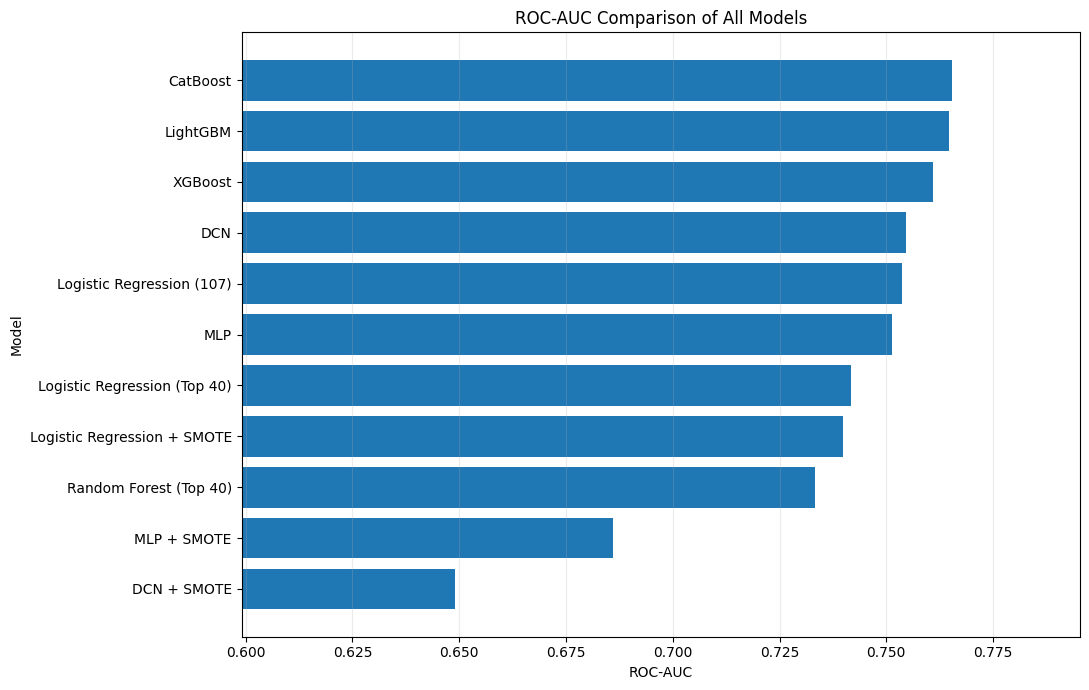

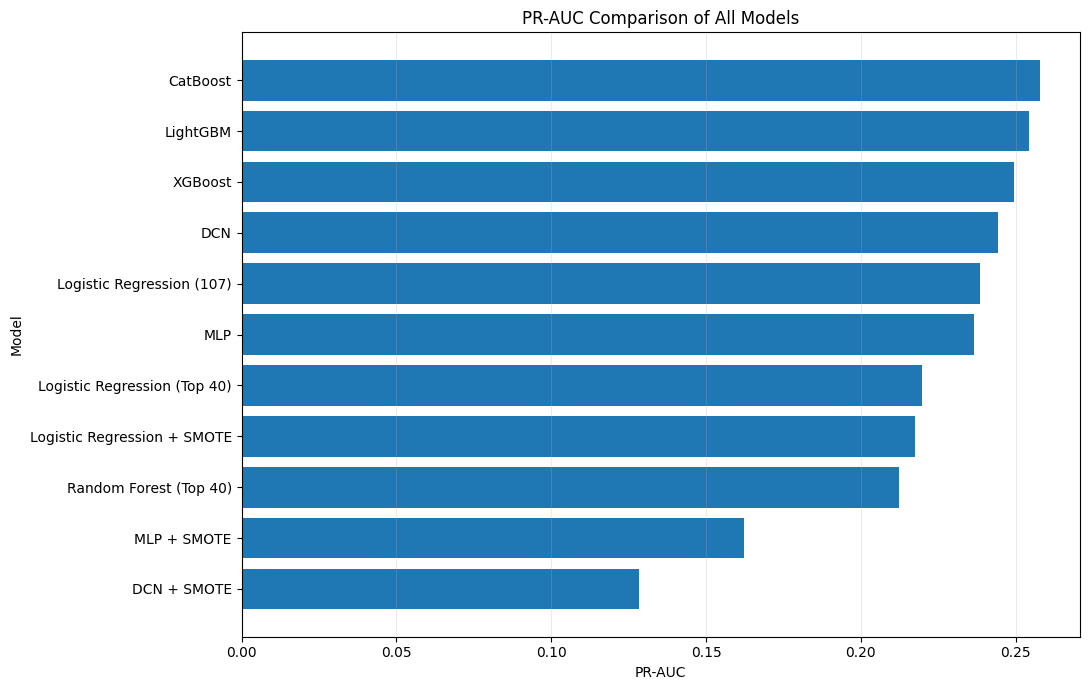

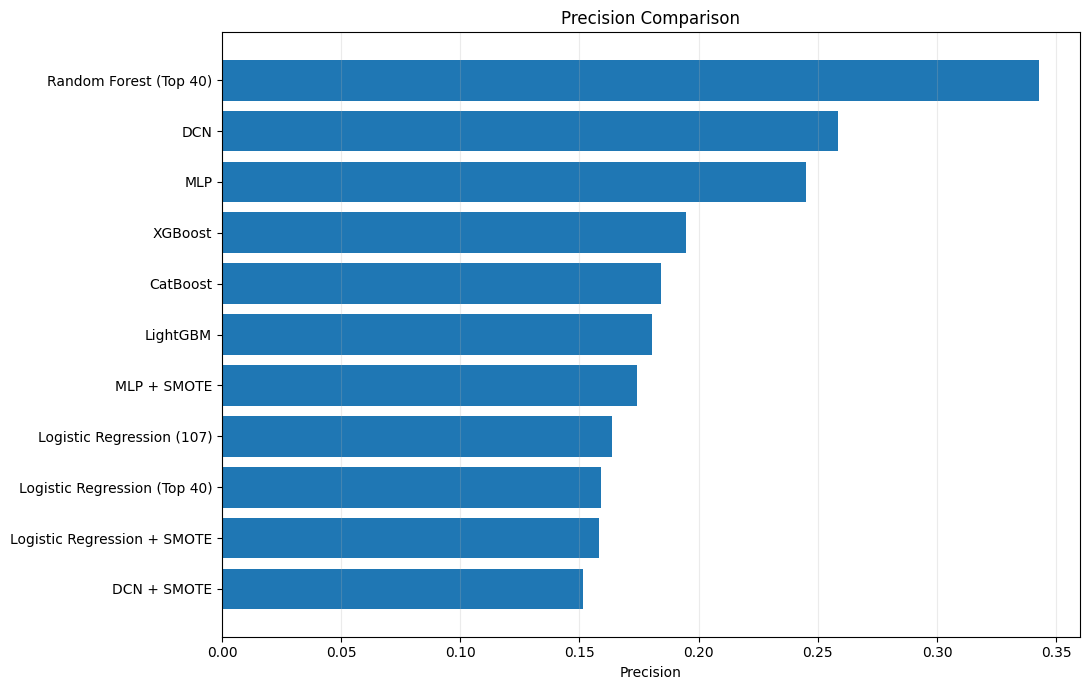

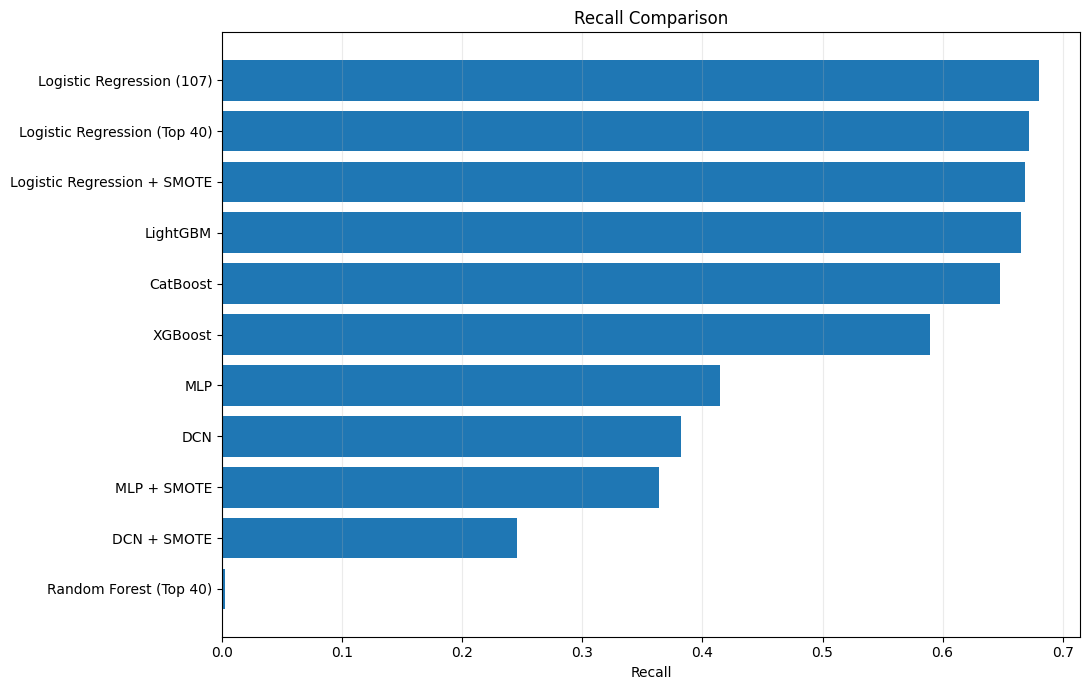

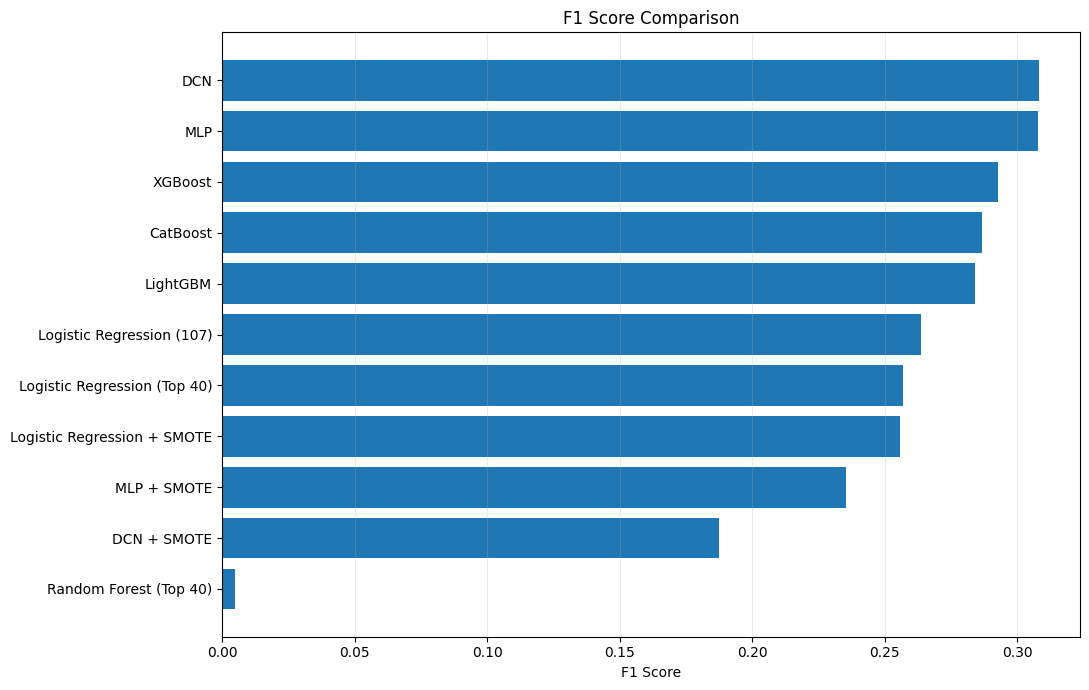

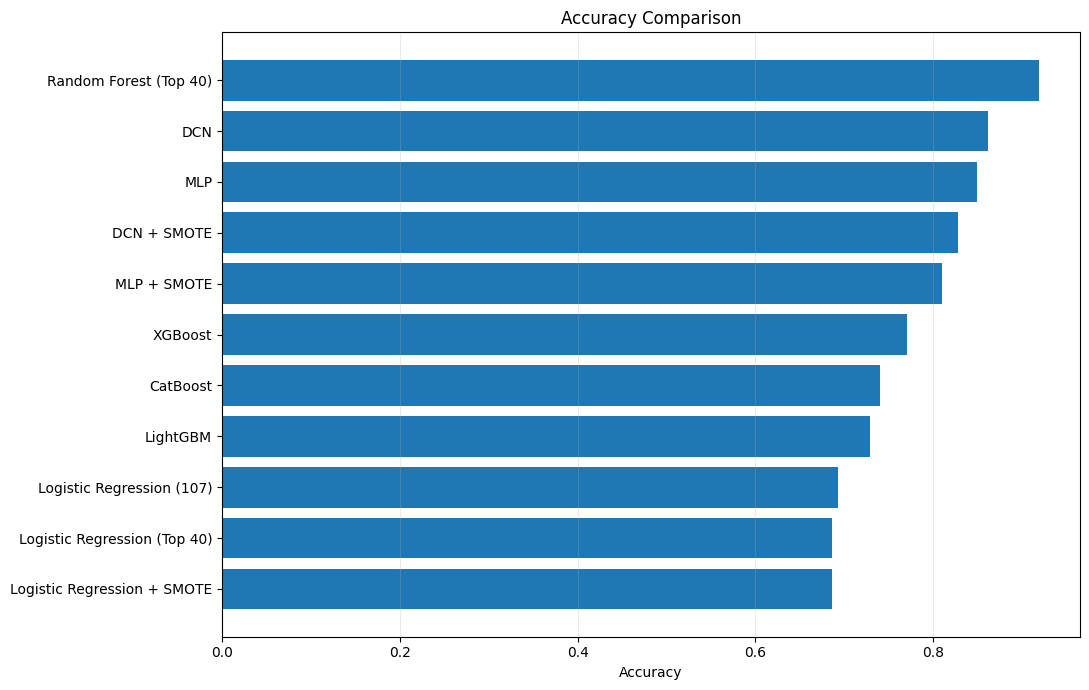

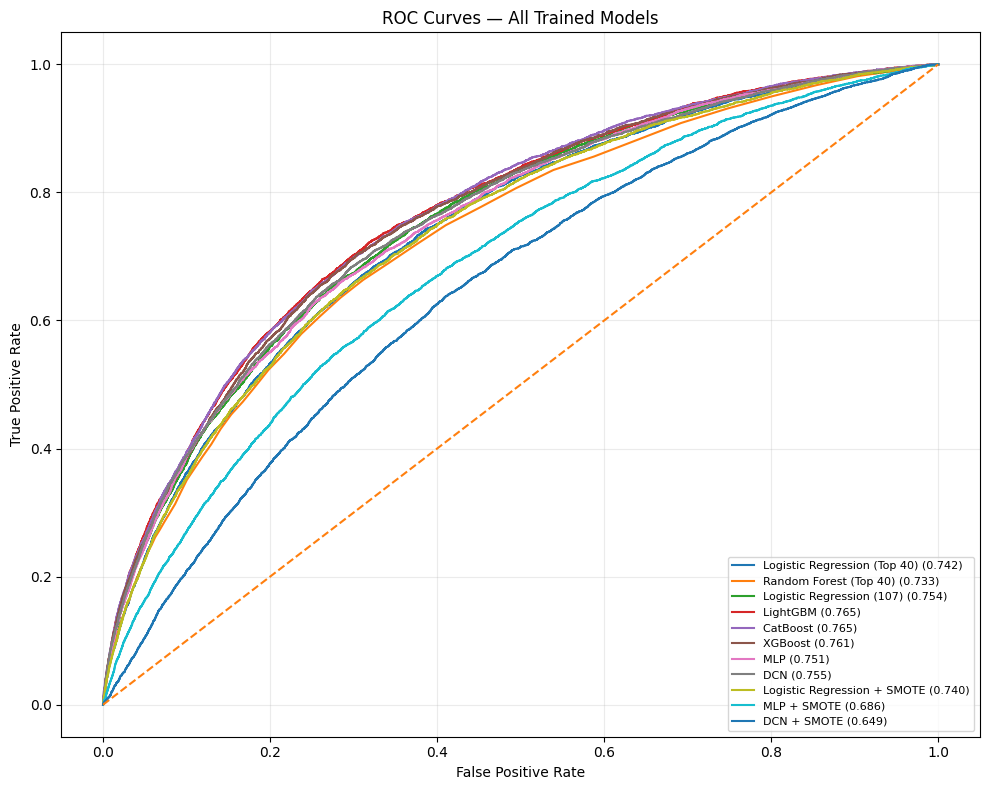

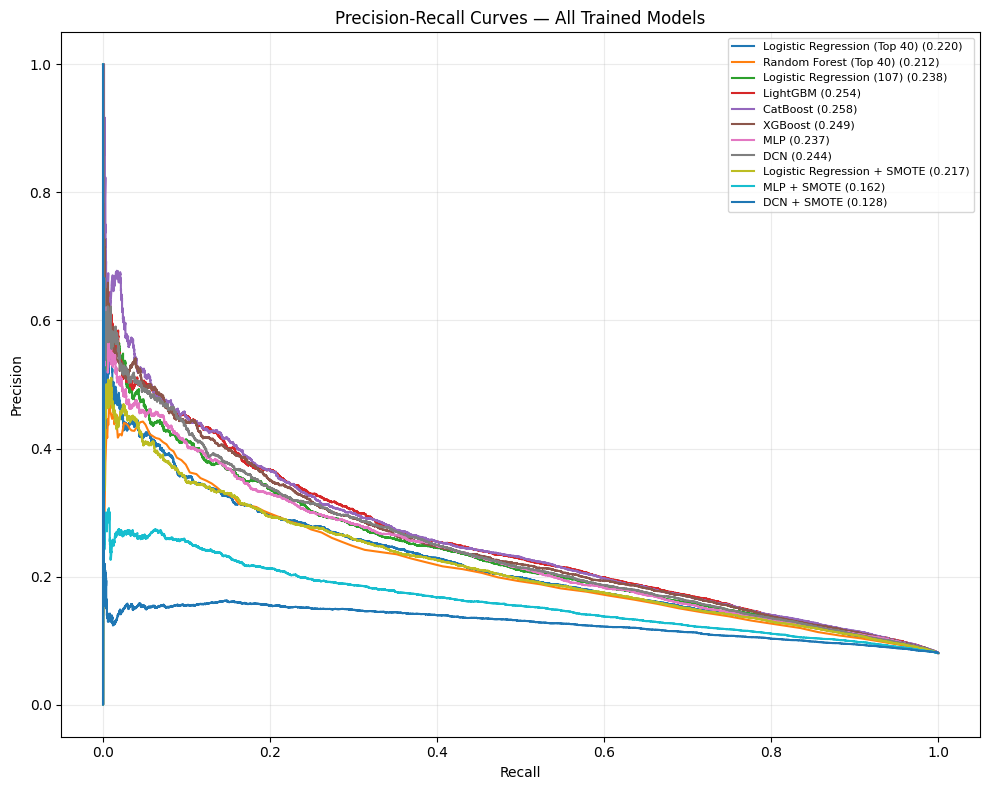

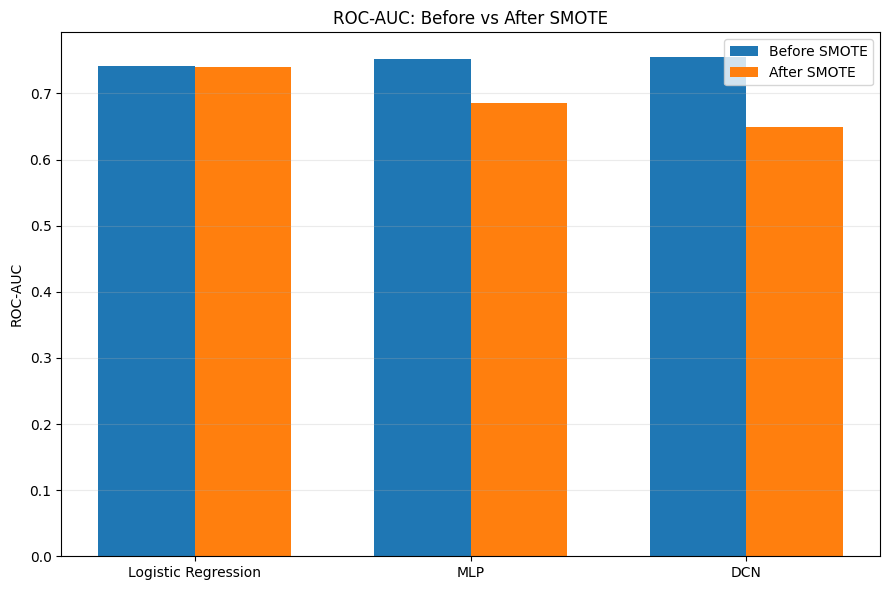

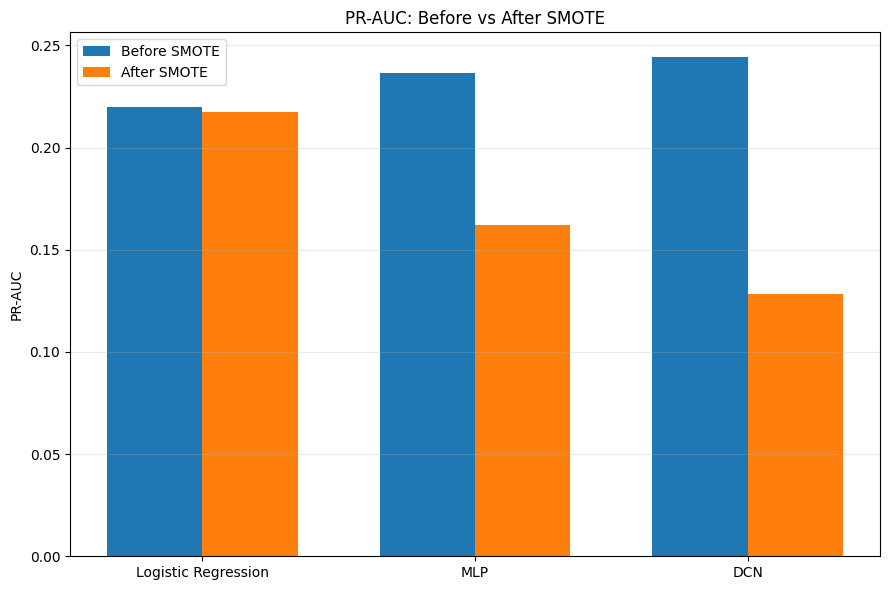

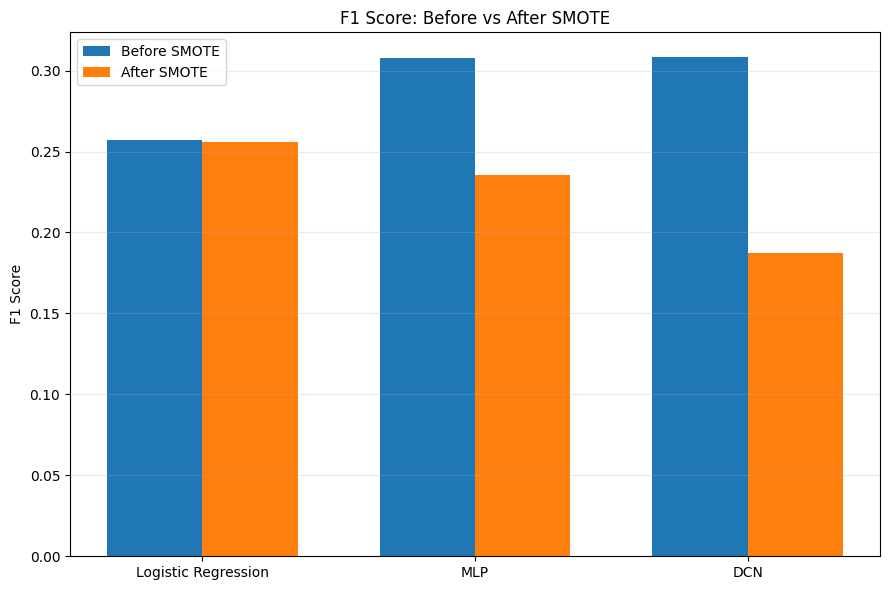

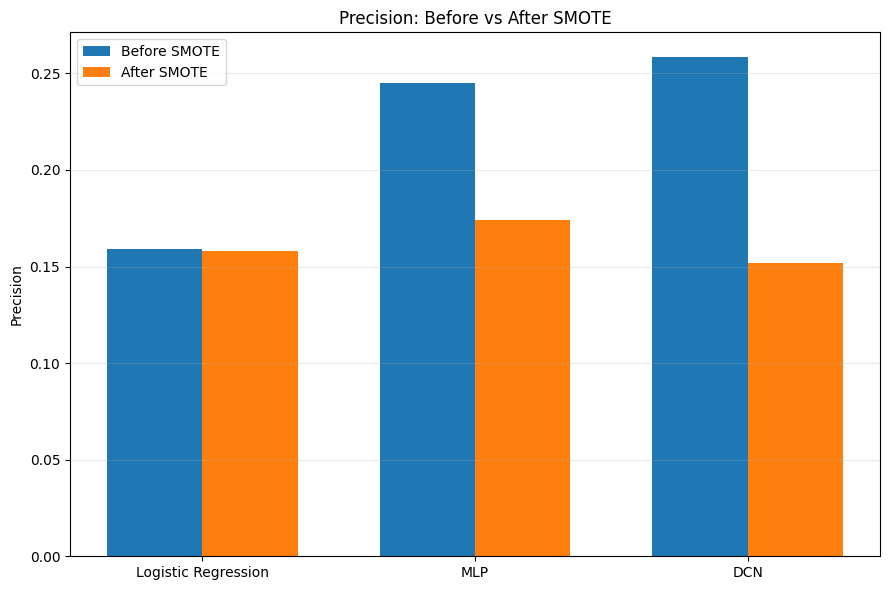

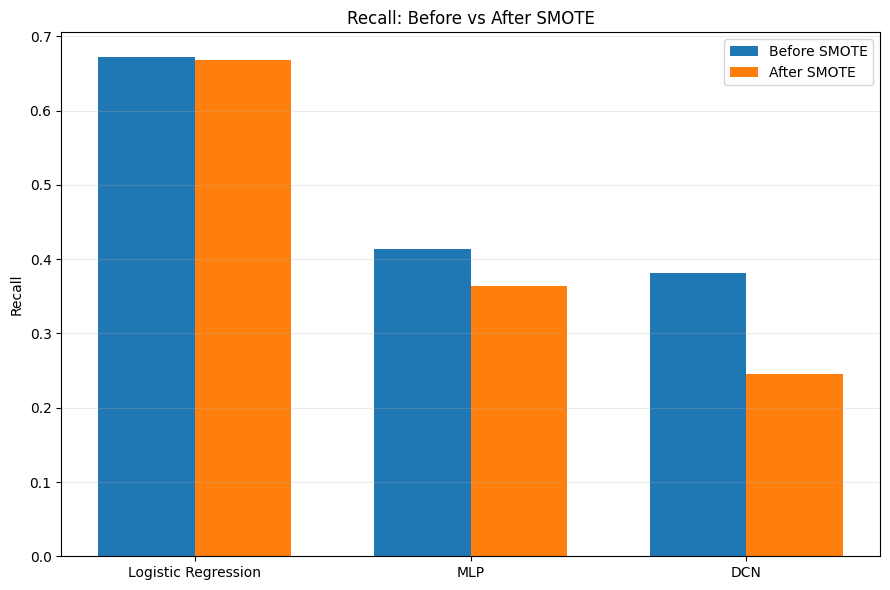

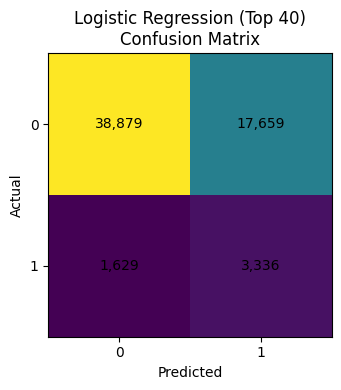

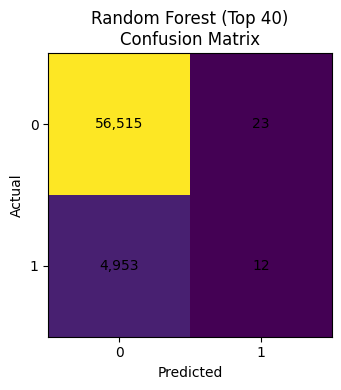

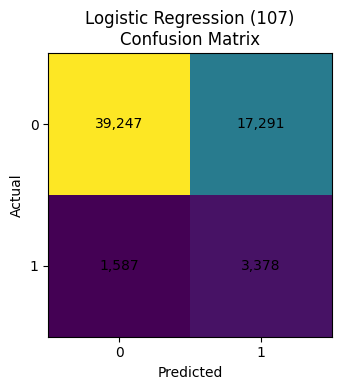

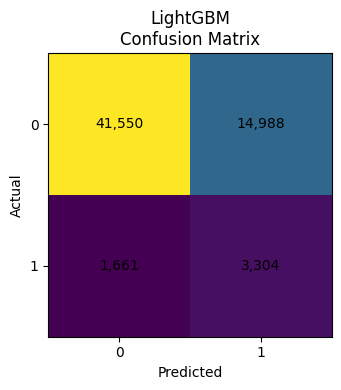

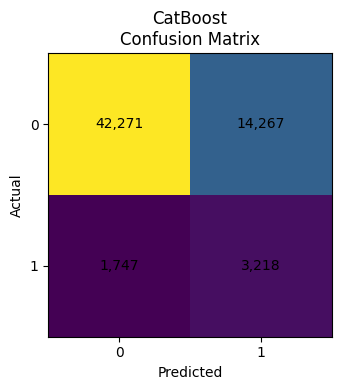

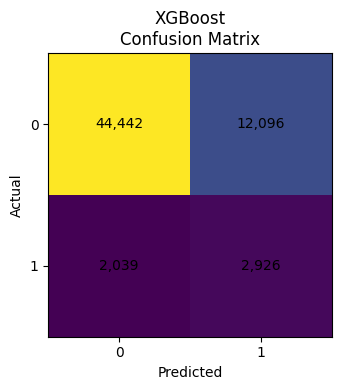

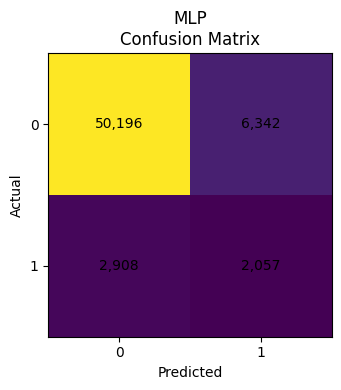

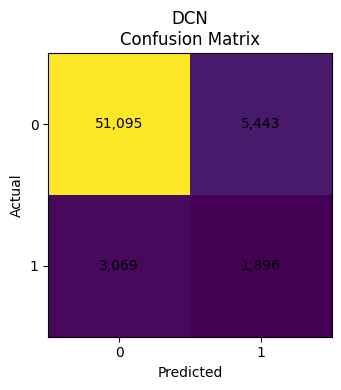

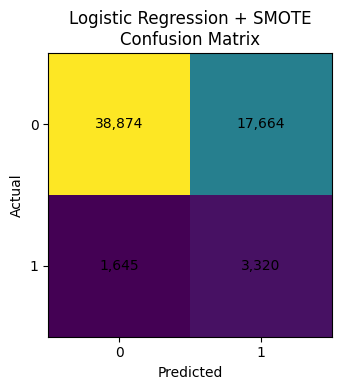

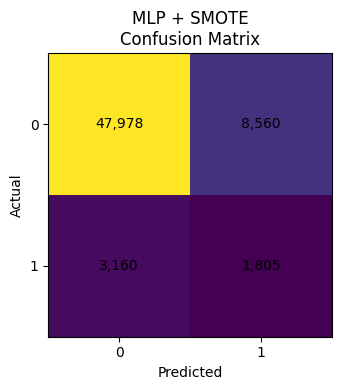

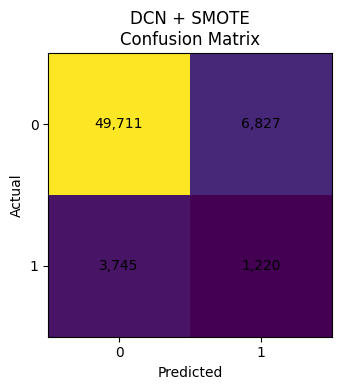



TOP MODELS BY ROC-AUC


,Model,ROC-AUC,PR-AUC,F1,Recall,Precision,Accuracy
0,CatBoost,0.7654,0.2578,0.2867,0.6481,0.1840,0.7396
1,LightGBM,0.7647,0.2544,0.2841,0.6655,0.1806,0.7293
2,XGBoost,0.7609,0.2495,0.2928,0.5893,0.1948,0.7702
3,DCN,0.7546,0.2442,0.3082,0.3819,0.2583,0.8616
4,Logistic Regression (107),0.7538,0.2384,0.2636,0.6804,0.1634,0.6931
5,MLP,0.7515,0.2367,0.3078,0.4143,0.2449,0.8496
6,Logistic Regression (Top 40),0.7418,0.2196,0.2570,0.6719,0.1589,0.6864
7,Logistic Regression + SMOTE,0.7399,0.2174,0.2559,0.6687,0.1582,0.6860
8,Random Forest (Top 40),0.7332,0.2123,0.0048,0.0024,0.3429,0.9191
9,MLP + SMOTE,0.6860,0.1623,0.2355,0.3635,0.1741,0.8094




BEST MODEL FOR EACH METRIC
Accuracy  : Random Forest (Top 40)              0.9191
Precision : Random Forest (Top 40)              0.3429
Recall    : Logistic Regression (107)           0.6804
F1        : DCN                                 0.3082
ROC-AUC   : CatBoost                            0.7654
PR-AUC    : CatBoost                            0.2578

MODEL SUMMARY COMPLETE


In [ ]:
# ================================================================
# COMPLETE MODEL PERFORMANCE SUMMARY + ALL COMPARISON PLOTS
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

# ================================================================
# 1. HELPER FUNCTION
# ================================================================

all_results = []
all_predictions = {}

def add_model_result(name, y_true, y_pred, y_prob, group="Original"):

    result = {
        "Model": name,
        "Group": group,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true, y_prob
        ),
        "PR-AUC": average_precision_score(
            y_true, y_prob
        )
    }

    all_results.append(result)

    all_predictions[name] = {
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
        "y_prob": np.asarray(y_prob)
    }


# ================================================================
# 2. LOGISTIC REGRESSION — TOP 40
# ================================================================

add_model_result(
    "Logistic Regression (Top 40)",
    y_val,
    y_val_pred_lr40,
    y_val_prob_lr40,
    "Original"
)


# ================================================================
# 3. RANDOM FOREST — TOP 40
# ================================================================

add_model_result(
    "Random Forest (Top 40)",
    y_val,
    y_val_pred_rf40,
    y_val_prob_rf40,
    "Original"
)


# ================================================================
# 4. LOGISTIC REGRESSION — 107 FEATURES
# ================================================================

add_model_result(
    "Logistic Regression (107)",
    y_val,
    y_val_pred_lr107,
    y_val_prob_lr107,
    "Original"
)


# ================================================================
# 5. LIGHTGBM
# ================================================================

# Recreate class prediction if necessary
if "y_val_pred_lgb" not in globals():
    y_val_pred_lgb = (
        y_val_prob_lgb >= 0.50
    ).astype(int)

add_model_result(
    "LightGBM",
    y_val,
    y_val_pred_lgb,
    y_val_prob_lgb,
    "Boosting"
)


# ================================================================
# 6. CATBOOST
# ================================================================

# CatBoost probability already exists.
# Use standard 0.50 threshold for classification metrics.

y_val_pred_cat_summary = (
    y_val_prob_cat >= 0.50
).astype(int)

add_model_result(
    "CatBoost",
    y_val,
    y_val_pred_cat_summary,
    y_val_prob_cat,
    "Boosting"
)


# ================================================================
# 7. XGBOOST
# ================================================================

y_val_pred_xgb_summary = (
    y_val_prob_xgb >= 0.50
).astype(int)

add_model_result(
    "XGBoost",
    y_val,
    y_val_pred_xgb_summary,
    y_val_prob_xgb,
    "Boosting"
)


# ================================================================
# 8. ORIGINAL MLP
# ================================================================

if (
    "y_val_pred_mlp" in globals()
    and "y_val_prob_mlp" in globals()
):

    y_true_mlp = (
        y_val_mlp
        if "y_val_mlp" in globals()
        else y_val
    )

    add_model_result(
        "MLP",
        y_true_mlp,
        y_val_pred_mlp,
        y_val_prob_mlp,
        "Neural Network"
    )


# ================================================================
# 9. ORIGINAL DCN
# ================================================================

if (
    "y_val_pred_dcn" in globals()
    and "y_val_prob_dcn" in globals()
):

    y_true_dcn = (
        y_val_dcn
        if "y_val_dcn" in globals()
        else y_val
    )

    add_model_result(
        "DCN",
        y_true_dcn,
        y_val_pred_dcn,
        y_val_prob_dcn,
        "Neural Network"
    )


# ================================================================
# 10. LOGISTIC REGRESSION + SMOTE
# ================================================================

if (
    "y_val_pred_smote" in globals()
    and "y_val_prob_smote" in globals()
):

    add_model_result(
        "Logistic Regression + SMOTE",
        y_val,
        y_val_pred_smote,
        y_val_prob_smote,
        "SMOTE"
    )


# ================================================================
# 11. MLP + SMOTE
# ================================================================

if "mlp_smote" in globals():

    mlp_smote_prob = mlp_smote.predict_proba(
        X_val_scaled_smote
    )[:, 1]

    mlp_smote_pred = mlp_smote.predict(
        X_val_scaled_smote
    )

    add_model_result(
        "MLP + SMOTE",
        y_val,
        mlp_smote_pred,
        mlp_smote_prob,
        "SMOTE"
    )


# ================================================================
# 12. DCN + SMOTE
# ================================================================

if "dcn_smote" in globals():

    dcn_smote_prob = dcn_smote.predict_proba(
        X_val_scaled_smote
    )[:, 1]

    dcn_smote_pred = dcn_smote.predict(
        X_val_scaled_smote
    )

    add_model_result(
        "DCN + SMOTE",
        y_val,
        dcn_smote_pred,
        dcn_smote_prob,
        "SMOTE"
    )


# ================================================================
# 13. CREATE FINAL SUMMARY TABLE
# ================================================================

model_summary_all = pd.DataFrame(
    all_results
)

model_summary_all = model_summary_all.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 105)
print("                    COMPLETE MODEL PERFORMANCE SUMMARY")
print("=" * 105)

display(
    model_summary_all.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)


# ================================================================
# 14. ROC-AUC COMPARISON
# ================================================================

plot_df = model_summary_all.sort_values(
    "ROC-AUC",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_df["Model"],
    plot_df["ROC-AUC"]
)

plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.title("ROC-AUC Comparison of All Models")

plt.xlim(
    max(0, plot_df["ROC-AUC"].min() - 0.05),
    min(1, plot_df["ROC-AUC"].max() + 0.03)
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ================================================================
# 15. PR-AUC COMPARISON
# ================================================================

plot_df = model_summary_all.sort_values(
    "PR-AUC",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_df["Model"],
    plot_df["PR-AUC"]
)

plt.xlabel("PR-AUC")
plt.ylabel("Model")
plt.title("PR-AUC Comparison of All Models")

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ================================================================
# 16. PRECISION COMPARISON
# ================================================================

plot_df = model_summary_all.sort_values(
    "Precision",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_df["Model"],
    plot_df["Precision"]
)

plt.xlabel("Precision")
plt.title("Precision Comparison")

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ================================================================
# 17. RECALL COMPARISON
# ================================================================

plot_df = model_summary_all.sort_values(
    "Recall",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_df["Model"],
    plot_df["Recall"]
)

plt.xlabel("Recall")
plt.title("Recall Comparison")

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ================================================================
# 18. F1-SCORE COMPARISON
# ================================================================

plot_df = model_summary_all.sort_values(
    "F1",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_df["Model"],
    plot_df["F1"]
)

plt.xlabel("F1 Score")
plt.title("F1 Score Comparison")

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ================================================================
# 19. ACCURACY COMPARISON
# ================================================================

plot_df = model_summary_all.sort_values(
    "Accuracy",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_df["Model"],
    plot_df["Accuracy"]
)

plt.xlabel("Accuracy")
plt.title("Accuracy Comparison")

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ================================================================
# 20. ROC CURVES — ALL MODELS
# ================================================================

plt.figure(figsize=(10, 8))

for model_name, values in all_predictions.items():

    fpr, tpr, _ = roc_curve(
        values["y_true"],
        values["y_prob"]
    )

    auc = roc_auc_score(
        values["y_true"],
        values["y_prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} ({auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves — All Trained Models"
)

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ================================================================
# 21. PRECISION-RECALL CURVES — ALL MODELS
# ================================================================

plt.figure(figsize=(10, 8))

for model_name, values in all_predictions.items():

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            values["y_true"],
            values["y_prob"]
        )
    )

    pr_auc = average_precision_score(
        values["y_true"],
        values["y_prob"]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{model_name} ({pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curves — All Trained Models"
)

plt.legend(
    fontsize=8
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ================================================================
# 22. BEFORE vs AFTER SMOTE
# ================================================================

smote_models = [
    "Logistic Regression",
    "MLP",
    "DCN"
]

before_names = [
    "Logistic Regression (Top 40)",
    "MLP",
    "DCN"
]

after_names = [
    "Logistic Regression + SMOTE",
    "MLP + SMOTE",
    "DCN + SMOTE"
]

smote_comparison = []

for base, before, after in zip(
    smote_models,
    before_names,
    after_names
):

    before_row = model_summary_all[
        model_summary_all["Model"] == before
    ]

    after_row = model_summary_all[
        model_summary_all["Model"] == after
    ]

    if (
        len(before_row) > 0
        and len(after_row) > 0
    ):

        for metric in [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC"
        ]:

            smote_comparison.append({
                "Model": base,
                "Metric": metric,
                "Before SMOTE":
                    before_row.iloc[0][metric],
                "After SMOTE":
                    after_row.iloc[0][metric]
            })


smote_df = pd.DataFrame(
    smote_comparison
)


# ================================================================
# 23. SMOTE ROC-AUC BEFORE vs AFTER
# ================================================================

roc_smote = smote_df[
    smote_df["Metric"] == "ROC-AUC"
].copy()

x = np.arange(
    len(roc_smote)
)

width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width/2,
    roc_smote["Before SMOTE"],
    width,
    label="Before SMOTE"
)

plt.bar(
    x + width/2,
    roc_smote["After SMOTE"],
    width,
    label="After SMOTE"
)

plt.xticks(
    x,
    roc_smote["Model"]
)

plt.ylabel("ROC-AUC")

plt.title(
    "ROC-AUC: Before vs After SMOTE"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ================================================================
# 24. SMOTE PR-AUC BEFORE vs AFTER
# ================================================================

pr_smote = smote_df[
    smote_df["Metric"] == "PR-AUC"
].copy()

# Logistic Regression before-SMOTE PR-AUC can be calculated
# directly from its stored probabilities.

if len(pr_smote) > 0:

    x = np.arange(
        len(pr_smote)
    )

    plt.figure(figsize=(9, 6))

    plt.bar(
        x - width/2,
        pr_smote["Before SMOTE"],
        width,
        label="Before SMOTE"
    )

    plt.bar(
        x + width/2,
        pr_smote["After SMOTE"],
        width,
        label="After SMOTE"
    )

    plt.xticks(
        x,
        pr_smote["Model"]
    )

    plt.ylabel("PR-AUC")

    plt.title(
        "PR-AUC: Before vs After SMOTE"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 25. F1 BEFORE vs AFTER SMOTE
# ================================================================

f1_smote = smote_df[
    smote_df["Metric"] == "F1"
].copy()

if len(f1_smote) > 0:

    x = np.arange(
        len(f1_smote)
    )

    plt.figure(figsize=(9, 6))

    plt.bar(
        x - width/2,
        f1_smote["Before SMOTE"],
        width,
        label="Before SMOTE"
    )

    plt.bar(
        x + width/2,
        f1_smote["After SMOTE"],
        width,
        label="After SMOTE"
    )

    plt.xticks(
        x,
        f1_smote["Model"]
    )

    plt.ylabel("F1 Score")

    plt.title(
        "F1 Score: Before vs After SMOTE"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 26. PRECISION & RECALL — BEFORE vs AFTER SMOTE
# ================================================================

for metric in ["Precision", "Recall"]:

    temp = smote_df[
        smote_df["Metric"] == metric
    ].copy()

    if len(temp) == 0:
        continue

    x = np.arange(
        len(temp)
    )

    plt.figure(figsize=(9, 6))

    plt.bar(
        x - width/2,
        temp["Before SMOTE"],
        width,
        label="Before SMOTE"
    )

    plt.bar(
        x + width/2,
        temp["After SMOTE"],
        width,
        label="After SMOTE"
    )

    plt.xticks(
        x,
        temp["Model"]
    )

    plt.ylabel(metric)

    plt.title(
        f"{metric}: Before vs After SMOTE"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 27. CONFUSION MATRIX FOR EVERY MODEL
# ================================================================

for model_name, values in all_predictions.items():

    cm = confusion_matrix(
        values["y_true"],
        values["y_pred"]
    )

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(
        f"{model_name}\nConfusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        [0, 1],
        ["0", "1"]
    )

    plt.yticks(
        [0, 1],
        ["0", "1"]
    )

    # Write values inside matrix
    for i in range(2):
        for j in range(2):

            plt.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()


# ================================================================
# 28. FINAL RANKINGS
# ================================================================

print("\n")
print("=" * 80)
print("TOP MODELS BY ROC-AUC")
print("=" * 80)

display(
    model_summary_all[
        [
            "Model",
            "ROC-AUC",
            "PR-AUC",
            "F1",
            "Recall",
            "Precision",
            "Accuracy"
        ]
    ]
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .style.format({
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}",
        "F1": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Accuracy": "{:.4f}"
    })
)


print("\n")
print("=" * 80)
print("BEST MODEL FOR EACH METRIC")
print("=" * 80)

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]:

    best_index = model_summary_all[
        metric
    ].idxmax()

    best_model = model_summary_all.loc[
        best_index,
        "Model"
    ]

    best_score = model_summary_all.loc[
        best_index,
        metric
    ]

    print(
        f"{metric:<10}: "
        f"{best_model:<35} "
        f"{best_score:.4f}"
    )


print("\n" + "=" * 80)
print("MODEL SUMMARY COMPLETE")
print("=" * 80)

In [ ]:
# ================================================================
# DEPLOYMENT EXPORT
#
# Creates:
#
# model/
# ├── dcn/
# │   ├── model.pt
# │   ├── metadata.json
# │   ├── preprocessor.pkl
# │   └── feature_columns.json
# │
# ├── dcn_smote/
# │   ├── model.pkl
# │   ├── metadata.json
# │   ├── preprocessor.pkl
# │   └── feature_columns.json
# │
# ├── mlp_smote/
# │   ├── model.pkl
# │   ├── metadata.json
# │   ├── preprocessor.pkl
# │   └── feature_columns.json
# │
# └── logistic_regression_smote/
#     ├── model.pkl
#     ├── metadata.json
#     ├── preprocessor.pkl
#     └── feature_columns.json
#
# ================================================================

import os
import json
import joblib
import torch
import numpy as np
import pandas as pd

BASE_DIR = "model"

# ------------------------------------------------
# Deployment threshold
# MUST be between 0 and 1
# ------------------------------------------------

CLASSIFICATION_THRESHOLD = 0.50

assert 0 < CLASSIFICATION_THRESHOLD < 1

os.makedirs(BASE_DIR, exist_ok=True)


# ================================================================
# HELPER FUNCTIONS
# ================================================================

def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(
            obj,
            f,
            indent=4
        )


def verify_size(path, max_mb=100):

    size_mb = os.path.getsize(path) / (1024 * 1024)

    print(
        f"{os.path.basename(path):30s}"
        f"{size_mb:8.2f} MB"
    )

    if size_mb > max_mb:

        print(
            f"WARNING: {path} exceeds "
            f"{max_mb} MB"
        )

    return size_mb


def export_sklearn_model(
    folder_name,
    model,
    preprocessor,
    feature_names,
    model_description
):

    folder = os.path.join(
        BASE_DIR,
        folder_name
    )

    os.makedirs(
        folder,
        exist_ok=True
    )

    # ----------------------------------------
    # Ensure feature names are plain strings
    # ----------------------------------------

    feature_names = [
        str(x)
        for x in feature_names
    ]

    # ----------------------------------------
    # 1. MODEL
    # ----------------------------------------

    model_path = os.path.join(
        folder,
        "model.pkl"
    )

    joblib.dump(
        model,
        model_path
    )

    # ----------------------------------------
    # 2. PREPROCESSOR
    # ----------------------------------------

    preprocessor_path = os.path.join(
        folder,
        "preprocessor.pkl"
    )

    joblib.dump(
        preprocessor,
        preprocessor_path
    )

    # ----------------------------------------
    # 3. FEATURE COLUMNS JSON
    # ----------------------------------------

    feature_path = os.path.join(
        folder,
        "feature_columns.json"
    )

    save_json(
        feature_names,
        feature_path
    )

    # ----------------------------------------
    # 4. METADATA JSON
    # ----------------------------------------

    metadata = {

        "model_name": folder_name,

        "model_type": model_description,

        "framework": "scikit-learn",

        "task": "binary_classification",

        "target": "TARGET",

        # Required by deployment
        "classification_threshold":
            float(CLASSIFICATION_THRESHOLD),

        # Included also for compatibility
        "threshold":
            float(CLASSIFICATION_THRESHOLD),

        "positive_class": 1,

        "negative_class": 0,

        "prediction_type":
            "probability",

        "feature_count":
            len(feature_names),

        # Required feature order
        "feature_order":
            feature_names,

        "feature_columns_file":
            "feature_columns.json",

        "preprocessor_file":
            "preprocessor.pkl",

        "model_file":
            "model.pkl",

        "requires_preprocessing":
            True,

        "smote_used_during_training":
            True,

        "apply_smote_during_inference":
            False
    }

    metadata_path = os.path.join(
        folder,
        "metadata.json"
    )

    save_json(
        metadata,
        metadata_path
    )

    # ----------------------------------------
    # Verify
    # ----------------------------------------

    print("\n" + "=" * 65)
    print(folder_name.upper())
    print("=" * 65)

    verify_size(model_path)

    print(
        "Threshold:",
        metadata["classification_threshold"]
    )

    print(
        "Features:",
        len(feature_names)
    )

    print(
        "Saved:",
        folder
    )


# ================================================================
# DETERMINE SMOTE FEATURE ORDER
# ================================================================

if (
    "X_train_selected" in globals()
    and hasattr(
        X_train_selected,
        "columns"
    )
):

    smote_features = (
        X_train_selected
        .columns
        .tolist()
    )

elif "selected_features" in globals():

    smote_features = list(
        selected_features
    )

else:

    raise RuntimeError(
        "Could not find the selected feature list. "
        "Expected X_train_selected or selected_features."
    )


print(
    "SMOTE feature count:",
    len(smote_features)
)


# ================================================================
# 1. LOGISTIC REGRESSION + SMOTE
# ================================================================

export_sklearn_model(

    folder_name=
        "logistic_regression_smote",

    model=
        lr_smote,

    preprocessor=
        scaler_smote,

    feature_names=
        smote_features,

    model_description=
        "Logistic Regression + SMOTE"
)


# ================================================================
# 2. MLP + SMOTE
# ================================================================

export_sklearn_model(

    folder_name=
        "mlp_smote",

    model=
        mlp_smote,

    preprocessor=
        scaler_smote,

    feature_names=
        smote_features,

    model_description=
        "MLPClassifier + SMOTE"
)


# ================================================================
# 3. DCN + SMOTE
#
# NOTE:
# In your notebook this object is named dcn_smote.
# If it is currently sklearn MLPClassifier,
# this exports that trained object exactly as it exists.
# ================================================================

export_sklearn_model(

    folder_name=
        "dcn_smote",

    model=
        dcn_smote,

    preprocessor=
        scaler_smote,

    feature_names=
        smote_features,

    model_description=
        "DCN/Deep Network + SMOTE"
)


# ================================================================
# 4. ORIGINAL PYTORCH DCN
# ================================================================

dcn_folder = os.path.join(
    BASE_DIR,
    "dcn"
)

os.makedirs(
    dcn_folder,
    exist_ok=True
)


# ================================================================
# FIND DCN FEATURE ORDER
# ================================================================

if (
    "X_train_dcn" in globals()
    and hasattr(
        X_train_dcn,
        "columns"
    )
):

    dcn_features = (
        X_train_dcn
        .columns
        .tolist()
    )

elif (
    "X_train" in globals()
    and hasattr(
        X_train,
        "columns"
    )
):

    dcn_features = (
        X_train
        .columns
        .tolist()
    )

elif (
    "X_train_lgb" in globals()
    and hasattr(
        X_train_lgb,
        "columns"
    )
):

    dcn_features = (
        X_train_lgb
        .columns
        .tolist()
    )

else:

    raise RuntimeError(
        "Could not identify DCN feature columns. "
        "Expected X_train_dcn, X_train, "
        "or X_train_lgb."
    )


dcn_features = [
    str(x)
    for x in dcn_features
]


# ================================================================
# DCN PREPROCESSOR
# ================================================================

# Try likely scaler names from notebook.

if "scaler_dcn" in globals():

    dcn_preprocessor = scaler_dcn

elif "scaler" in globals():

    dcn_preprocessor = scaler

elif "scaler_mlp" in globals():

    dcn_preprocessor = scaler_mlp

else:

    raise RuntimeError(
        "DCN scaler/preprocessor was not found. "
        "The deployment requires the fitted scaler "
        "used when training the PyTorch DCN."
    )


# ================================================================
# SAVE PYTORCH DCN
# ================================================================

dcn_model.eval()

model_path = os.path.join(
    dcn_folder,
    "model.pt"
)


# ------------------------------------------------
# Preferred: TorchScript export
# Easier for deployment because architecture
# is embedded with the model.
# ------------------------------------------------

try:

    device = next(
        dcn_model.parameters()
    ).device

    example_input = torch.zeros(
        1,
        len(dcn_features),
        dtype=torch.float32,
        device=device
    )

    traced_model = torch.jit.trace(
        dcn_model,
        example_input
    )

    traced_model.save(
        model_path
    )

    pytorch_export_type = "TorchScript"

    print(
        "\nPyTorch DCN exported "
        "as TorchScript."
    )

except Exception as e:

    print(
        "\nTorchScript export failed:"
    )

    print(e)

    print(
        "\nFalling back to "
        "state_dict export."
    )

    model_path = os.path.join(
        dcn_folder,
        "model.pth"
    )

    torch.save(
        dcn_model.state_dict(),
        model_path
    )

    pytorch_export_type = "state_dict"


# ================================================================
# SAVE DCN PREPROCESSOR
# ================================================================

dcn_preprocessor_path = os.path.join(
    dcn_folder,
    "preprocessor.pkl"
)

joblib.dump(
    dcn_preprocessor,
    dcn_preprocessor_path
)


# ================================================================
# SAVE DCN FEATURE COLUMNS
# ================================================================

dcn_feature_path = os.path.join(
    dcn_folder,
    "feature_columns.json"
)

save_json(
    dcn_features,
    dcn_feature_path
)


# ================================================================
# SAVE DCN METADATA
# ================================================================

dcn_metadata = {

    "model_name":
        "dcn",

    "model_type":
        "Deep & Cross Network",

    "framework":
        "PyTorch",

    "export_type":
        pytorch_export_type,

    "task":
        "binary_classification",

    "target":
        "TARGET",

    # REQUIRED BY DEPLOYMENT
    "classification_threshold":
        float(
            CLASSIFICATION_THRESHOLD
        ),

    # Compatibility field
    "threshold":
        float(
            CLASSIFICATION_THRESHOLD
        ),

    "positive_class":
        1,

    "negative_class":
        0,

    "prediction_type":
        "probability",

    "feature_count":
        len(
            dcn_features
        ),

    # REQUIRED ORDER
    "feature_order":
        dcn_features,

    "feature_columns_file":
        "feature_columns.json",

    "preprocessor_file":
        "preprocessor.pkl",

    "model_file":
        os.path.basename(
            model_path
        ),

    "requires_preprocessing":
        True,

    "smote_used_during_training":
        False,

    "apply_smote_during_inference":
        False
}


save_json(

    dcn_metadata,

    os.path.join(
        dcn_folder,
        "metadata.json"
    )
)


print("\n" + "=" * 65)
print("DCN")
print("=" * 65)

verify_size(
    model_path
)

print(
    "Threshold:",
    dcn_metadata[
        "classification_threshold"
    ]
)

print(
    "Features:",
    len(
        dcn_features
    )
)

print(
    "Export type:",
    pytorch_export_type
)


# ================================================================
# FINAL DEPLOYMENT VALIDATION
# ================================================================

print("\n")
print("=" * 75)
print("VALIDATING DEPLOYMENT PACKAGES")
print("=" * 75)


folders = [

    "dcn",

    "dcn_smote",

    "mlp_smote",

    "logistic_regression_smote"
]


for folder_name in folders:

    folder = os.path.join(
        BASE_DIR,
        folder_name
    )

    metadata_file = os.path.join(
        folder,
        "metadata.json"
    )

    feature_file = os.path.join(
        folder,
        "feature_columns.json"
    )

    preprocessor_file = os.path.join(
        folder,
        "preprocessor.pkl"
    )


    # ----------------------------------------
    # Metadata validation
    # ----------------------------------------

    with open(
        metadata_file,
        "r",
        encoding="utf-8"
    ) as f:

        metadata = json.load(f)


    threshold = metadata.get(
        "classification_threshold"
    )


    assert threshold is not None, (
        f"{folder_name}: "
        "classification_threshold missing"
    )


    assert 0 <= threshold <= 1, (
        f"{folder_name}: "
        "invalid threshold"
    )


    # ----------------------------------------
    # Feature validation
    # ----------------------------------------

    with open(
        feature_file,
        "r",
        encoding="utf-8"
    ) as f:

        features = json.load(f)


    assert isinstance(
        features,
        list
    )

    assert len(features) > 0


    assert len(features) == metadata[
        "feature_count"
    ]


    # ----------------------------------------
    # Preprocessor
    # ----------------------------------------

    assert os.path.exists(
        preprocessor_file
    )


    # ----------------------------------------
    # Model
    # ----------------------------------------

    model_file = os.path.join(
        folder,
        metadata["model_file"]
    )

    assert os.path.exists(
        model_file
    )


    model_mb = (
        os.path.getsize(model_file)
        /
        (1024 * 1024)
    )


    status = (
        "PASS"
        if model_mb <= 100
        else "TOO LARGE"
    )


    print(
        f"\n{folder_name}"
    )

    print(
        f"  Model file      : "
        f"{metadata['model_file']}"
    )

    print(
        f"  Model size      : "
        f"{model_mb:.2f} MB"
    )

    print(
        f"  Threshold       : "
        f"{threshold}"
    )

    print(
        f"  Feature count   : "
        f"{len(features)}"
    )

    print(
        f"  Preprocessor    : "
        f"preprocessor.pkl"
    )

    print(
        f"  Feature JSON    : "
        f"feature_columns.json"
    )

    print(
        f"  Status          : "
        f"{status}"
    )


print("\n")
print("=" * 75)
print("DEPLOYMENT EXPORT COMPLETE")
print("=" * 75)

SMOTE feature count: 40

LOGISTIC_REGRESSION_SMOTE
model.pkl                         0.00 MB
Threshold: 0.5
Features: 40
Saved: model\logistic_regression_smote

MLP_SMOTE
model.pkl                         0.12 MB
Threshold: 0.5
Features: 40
Saved: model\mlp_smote

DCN_SMOTE
model.pkl                         1.24 MB
Threshold: 0.5
Features: 40
Saved: model\dcn_smote

PyTorch DCN exported as TorchScript.

DCN
model.pt                          0.30 MB
Threshold: 0.5
Features: 107
Export type: TorchScript


VALIDATING DEPLOYMENT PACKAGES

dcn
  Model file      : model.pt
  Model size      : 0.30 MB
  Threshold       : 0.5
  Feature count   : 107
  Preprocessor    : preprocessor.pkl
  Feature JSON    : feature_columns.json
  Status          : PASS

dcn_smote
  Model file      : model.pkl
  Model size      : 1.24 MB
  Threshold       : 0.5
  Feature count   : 40
  Preprocessor    : preprocessor.pkl
  Feature JSON    : feature_columns.json
  Status          : PASS

mlp_smote
  Model file     